In [52]:
import pandas as pd

In [53]:
df = pd.read_csv("results/reports/result_1000Epoch.csv")

In [54]:
df.head()

,Model,Test_Accuracy,Best_Val_Accuracy,Best_Val_f1,Best_Val_Loss,Precision,Recall,F1,Epochs,prep_windowing,prep_clahe,prep_median,prep_norm_type
0,resnet50_vgg16_inceptionv3_baseline_ep100,0.947867,0.976378,0.942480,0.121789,0.954101,0.947867,0.946740,100,NaN,NaN,NaN,NaN
1,resnet50_vgg16_inceptionv3_windowing_ep100,0.957346,0.732484,0.582586,0.836628,0.957635,0.957346,0.957466,100,True,NaN,NaN,NaN
2,resnet50_vgg16_inceptionv3_clahe_ep100,0.981043,0.960630,0.917183,0.132914,0.982777,0.981043,0.981409,100,NaN,True,NaN,NaN
3,resnet50_vgg16_inceptionv3_window_clahe_ep100,0.900474,0.944882,0.894451,0.230788,0.926668,0.900474,0.909316,100,True,True,NaN,NaN
4,resnet50_vgg16_inceptionv3_clahe_median_ep100,0.815166,0.811024,0.567760,0.505631,0.875237,0.815166,0.787622,100,NaN,True,True,NaN


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Model              35 non-null     object 
 1   Test_Accuracy      35 non-null     float64
 2   Best_Val_Accuracy  35 non-null     float64
 3   Best_Val_f1        35 non-null     float64
 4   Best_Val_Loss      35 non-null     float64
 5   Precision          35 non-null     float64
 6   Recall             35 non-null     float64
 7   F1                 35 non-null     float64
 8   Epochs             35 non-null     int64  
 9   prep_windowing     18 non-null     object 
 10  prep_clahe         23 non-null     object 
 11  prep_median        6 non-null      object 
 12  prep_norm_type     6 non-null      object 
dtypes: float64(7), int64(1), object(5)
memory usage: 3.7+ KB


In [56]:
df.columns = df.columns.str.strip()

In [58]:
cnn_model = [
    "resnet50",
    "vgg16",
    "inceptionv3",
    "efficientnetb0",
    "efficientnetb4",
    "densenet121"
]

In [59]:
def extract_info(name):
    parts = name.split("_")

    hybrid_model = []
    config_parts = []    
    epoch = None
    for p in parts:
        if p in cnn_model:
            print(p)
            hybrid_model.append(p)
        elif p.startswith("ep"):
            epoch = int(p.replace("ep",""))
        else:
            config_parts.append(p)
        
    print(hybrid_model)
    # parts = [p for p in parts if not p.startswith("ep")]

    hybrid_model = "_".join(hybrid_model)

    config = "_".join(config_parts)


    return pd.Series([hybrid_model,config,epoch])

df[["hybrid_model","config","epoch"]] = df["Model"].apply(extract_info)

# print(df.head())

resnet50
vgg16
inceptionv3
['resnet50', 'vgg16', 'inceptionv3']
resnet50
vgg16
inceptionv3
['resnet50', 'vgg16', 'inceptionv3']
resnet50
vgg16
inceptionv3
['resnet50', 'vgg16', 'inceptionv3']
resnet50
vgg16
inceptionv3
['resnet50', 'vgg16', 'inceptionv3']
resnet50
vgg16
inceptionv3
['resnet50', 'vgg16', 'inceptionv3']
resnet50
vgg16
inceptionv3
['resnet50', 'vgg16', 'inceptionv3']
resnet50
densenet121
efficientnetb4
['resnet50', 'densenet121', 'efficientnetb4']
resnet50
densenet121
efficientnetb4
['resnet50', 'densenet121', 'efficientnetb4']
resnet50
densenet121
efficientnetb4
['resnet50', 'densenet121', 'efficientnetb4']
resnet50
densenet121
efficientnetb4
['resnet50', 'densenet121', 'efficientnetb4']
resnet50
densenet121
efficientnetb4
['resnet50', 'densenet121', 'efficientnetb4']
resnet50
densenet121
efficientnetb4
['resnet50', 'densenet121', 'efficientnetb4']
resnet50
vgg16
efficientnetb0
['resnet50', 'vgg16', 'efficientnetb0']
resnet50
vgg16
efficientnetb0
['resnet50', 'vgg16', 'e

In [60]:
def extract_info(name):
    parts = name.split("_")

    hybrid_model = []
    config_parts = []    
    epoch = None

    for p in parts:
        if p in cnn_model:
            hybrid_model.append(p)
        elif p.startswith("ep"):
            try:
                epoch = int(p.replace("ep", ""))
            except:
                epoch = None
        else:
            config_parts.append(p)

    return pd.Series([
        hybrid_model,              # LIST 👈 important
        "_".join(config_parts),
        epoch
    ])
    
df[["hybrid_model_list","config","epoch"]] = df["Model"].apply(extract_info)

In [61]:
len(df["hybrid_model"].unique())

6

In [62]:
df["hybrid_model"].unique()

array(['resnet50_vgg16_inceptionv3',
       'resnet50_densenet121_efficientnetb4',
       'resnet50_vgg16_efficientnetb0',
       'resnet50_densenet121_inceptionv3',
       'resnet50_efficientnetb4_inceptionv3',
       'resnet50_vgg16_inceptionv3_efficientnetb0'], dtype=object)

In [63]:
df["hybrid_model"]

0                    resnet50_vgg16_inceptionv3
1                    resnet50_vgg16_inceptionv3
2                    resnet50_vgg16_inceptionv3
3                    resnet50_vgg16_inceptionv3
4                    resnet50_vgg16_inceptionv3
5                    resnet50_vgg16_inceptionv3
6           resnet50_densenet121_efficientnetb4
7           resnet50_densenet121_efficientnetb4
8           resnet50_densenet121_efficientnetb4
9           resnet50_densenet121_efficientnetb4
10          resnet50_densenet121_efficientnetb4
11          resnet50_densenet121_efficientnetb4
12                resnet50_vgg16_efficientnetb0
13                resnet50_vgg16_efficientnetb0
14                resnet50_vgg16_efficientnetb0
15                resnet50_vgg16_efficientnetb0
16                resnet50_vgg16_efficientnetb0
17                resnet50_vgg16_efficientnetb0
18             resnet50_densenet121_inceptionv3
19             resnet50_densenet121_inceptionv3
20             resnet50_densenet121_ince

In [64]:
(df.groupby("hybrid_model")['config'].count())

hybrid_model
resnet50_densenet121_efficientnetb4          6
resnet50_densenet121_inceptionv3             5
resnet50_efficientnetb4_inceptionv3          6
resnet50_vgg16_efficientnetb0                6
resnet50_vgg16_inceptionv3                   6
resnet50_vgg16_inceptionv3_efficientnetb0    6
Name: config, dtype: int64

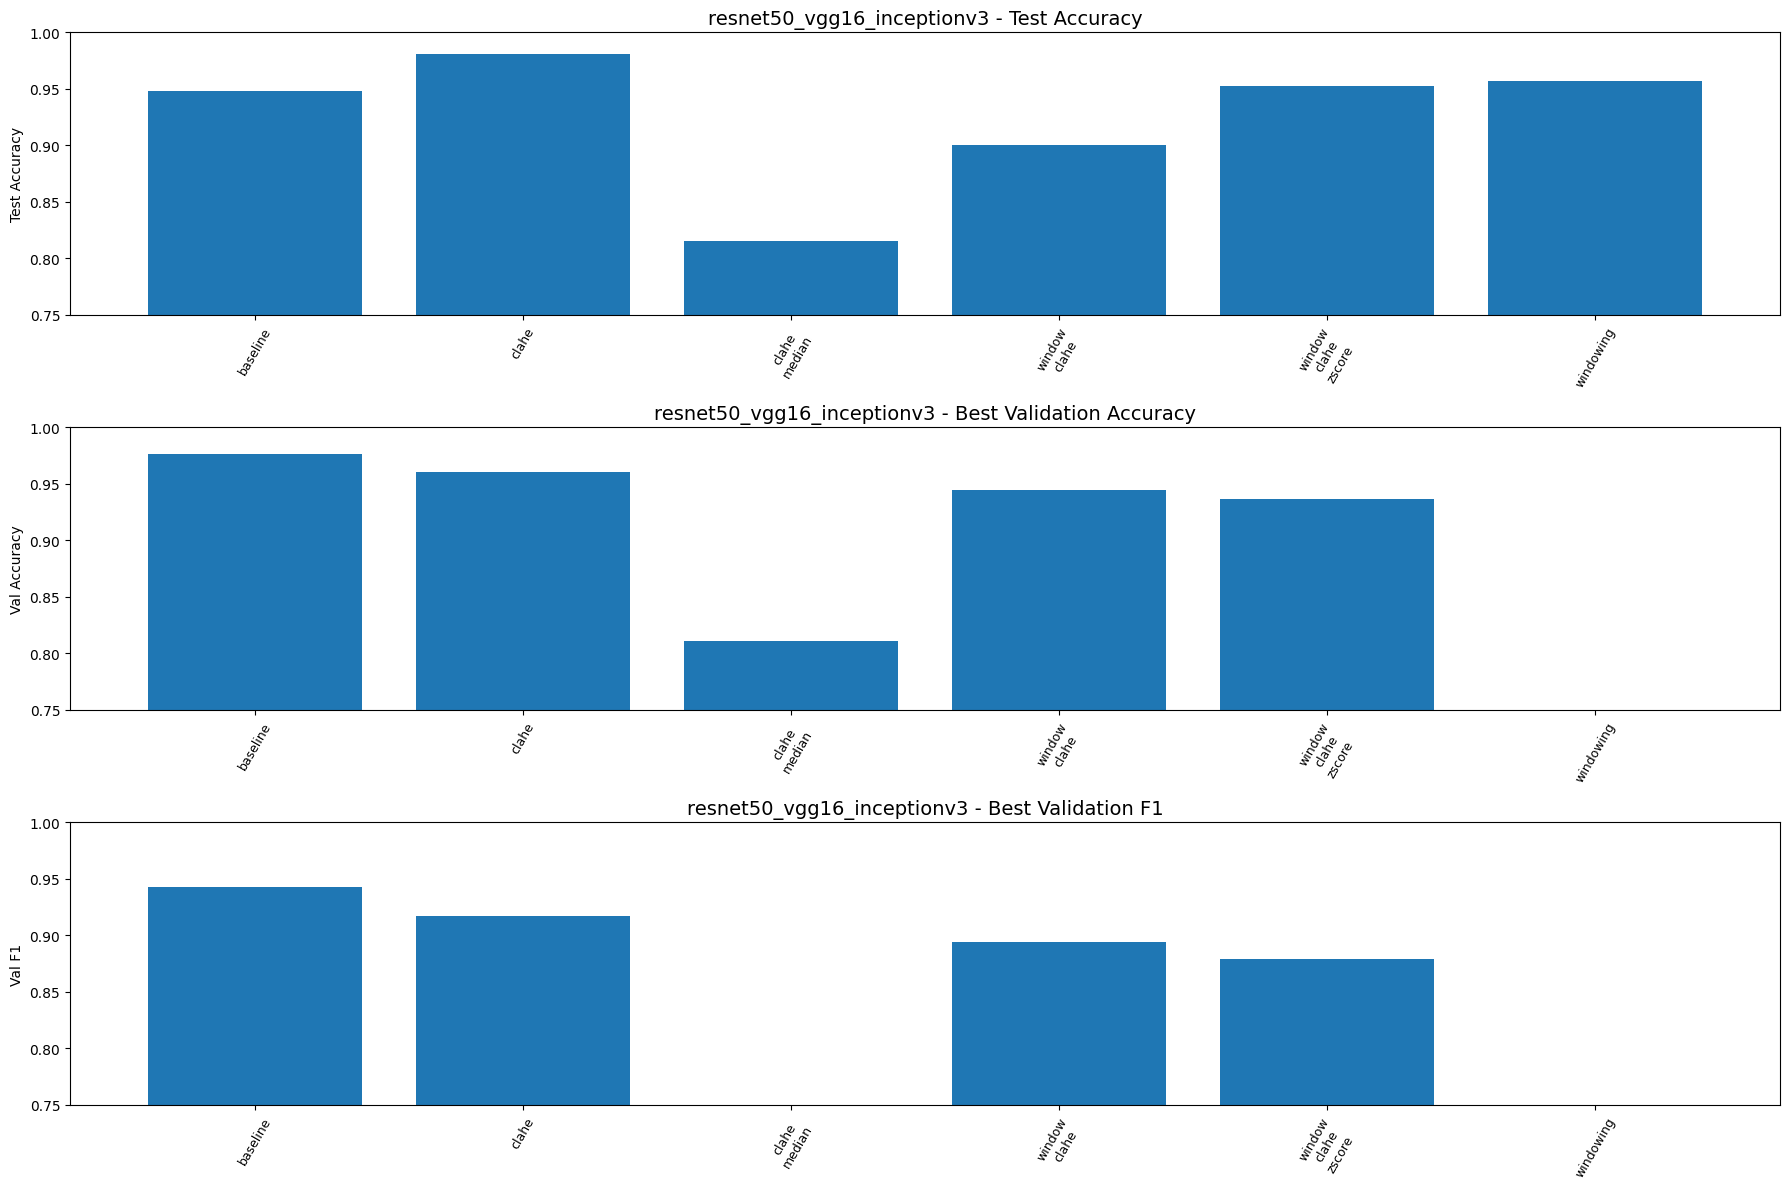

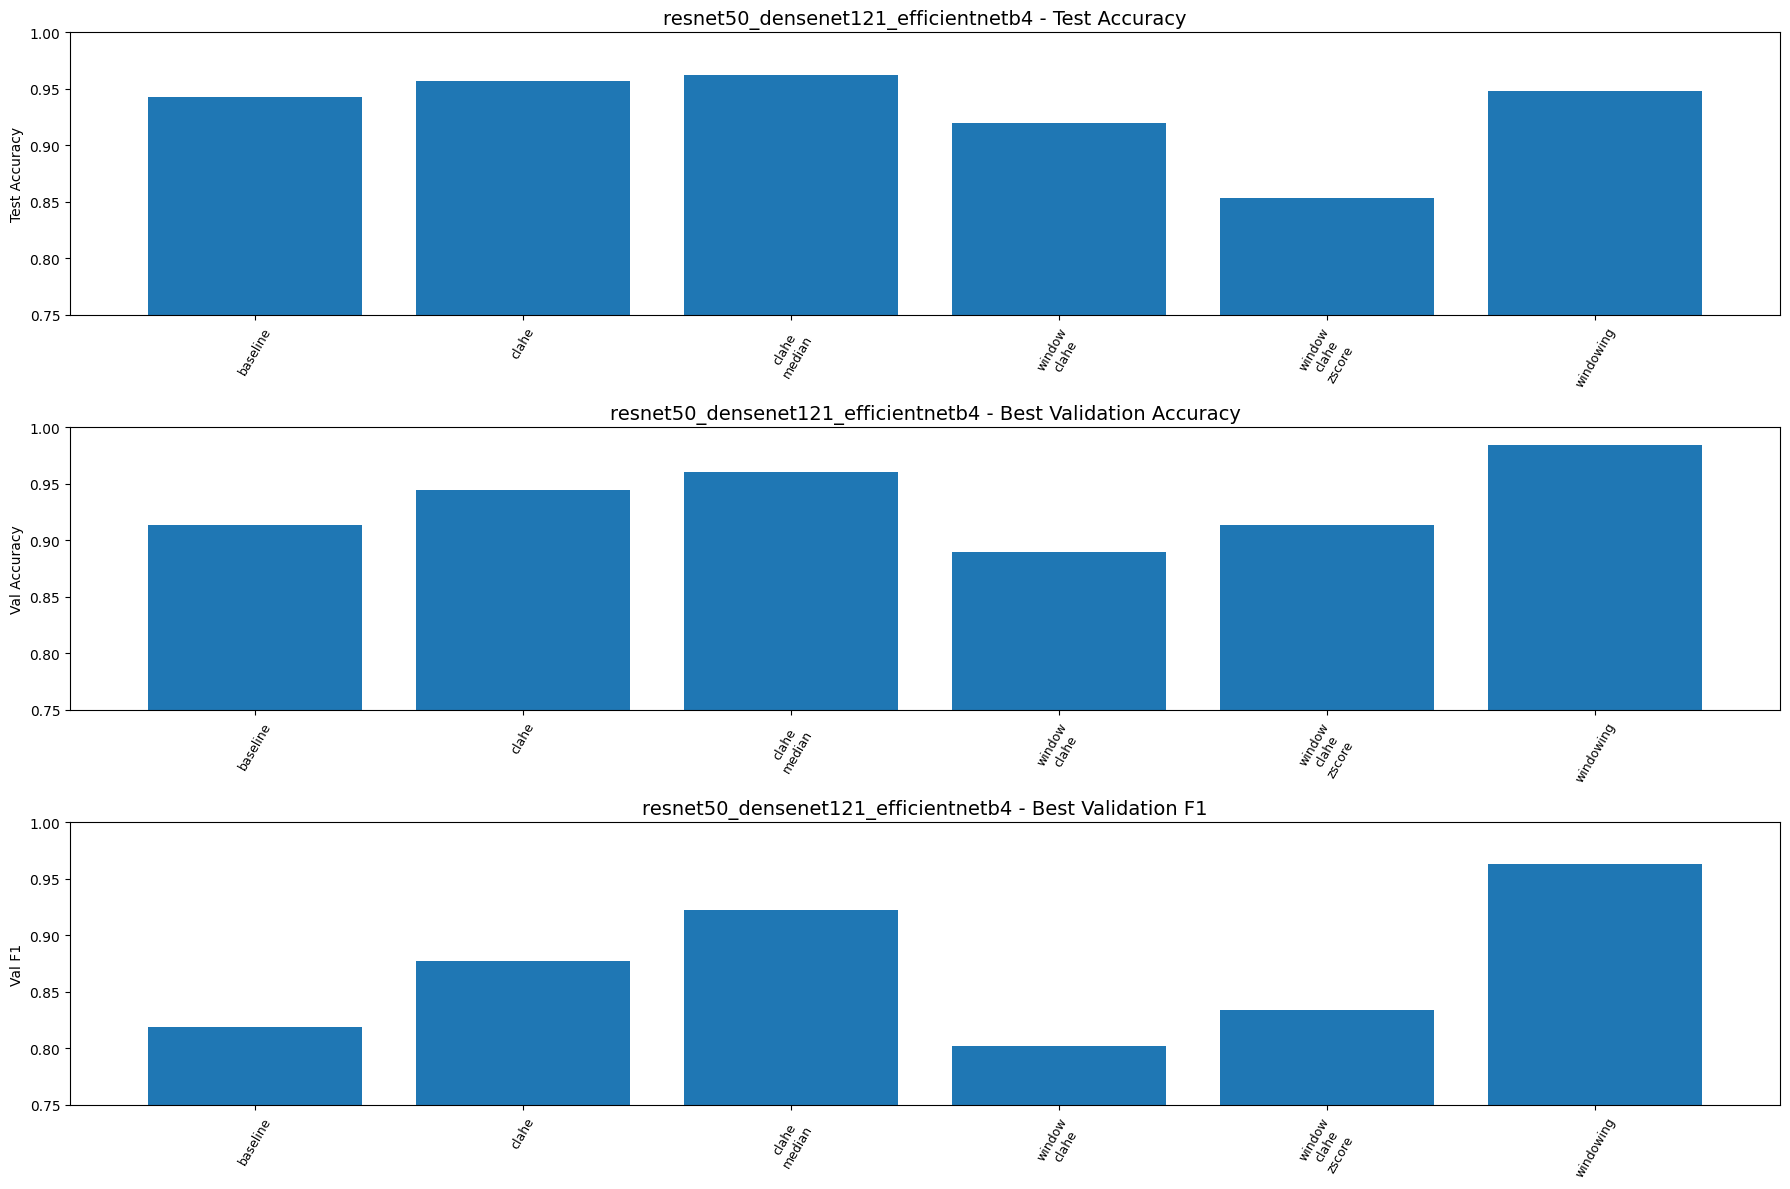

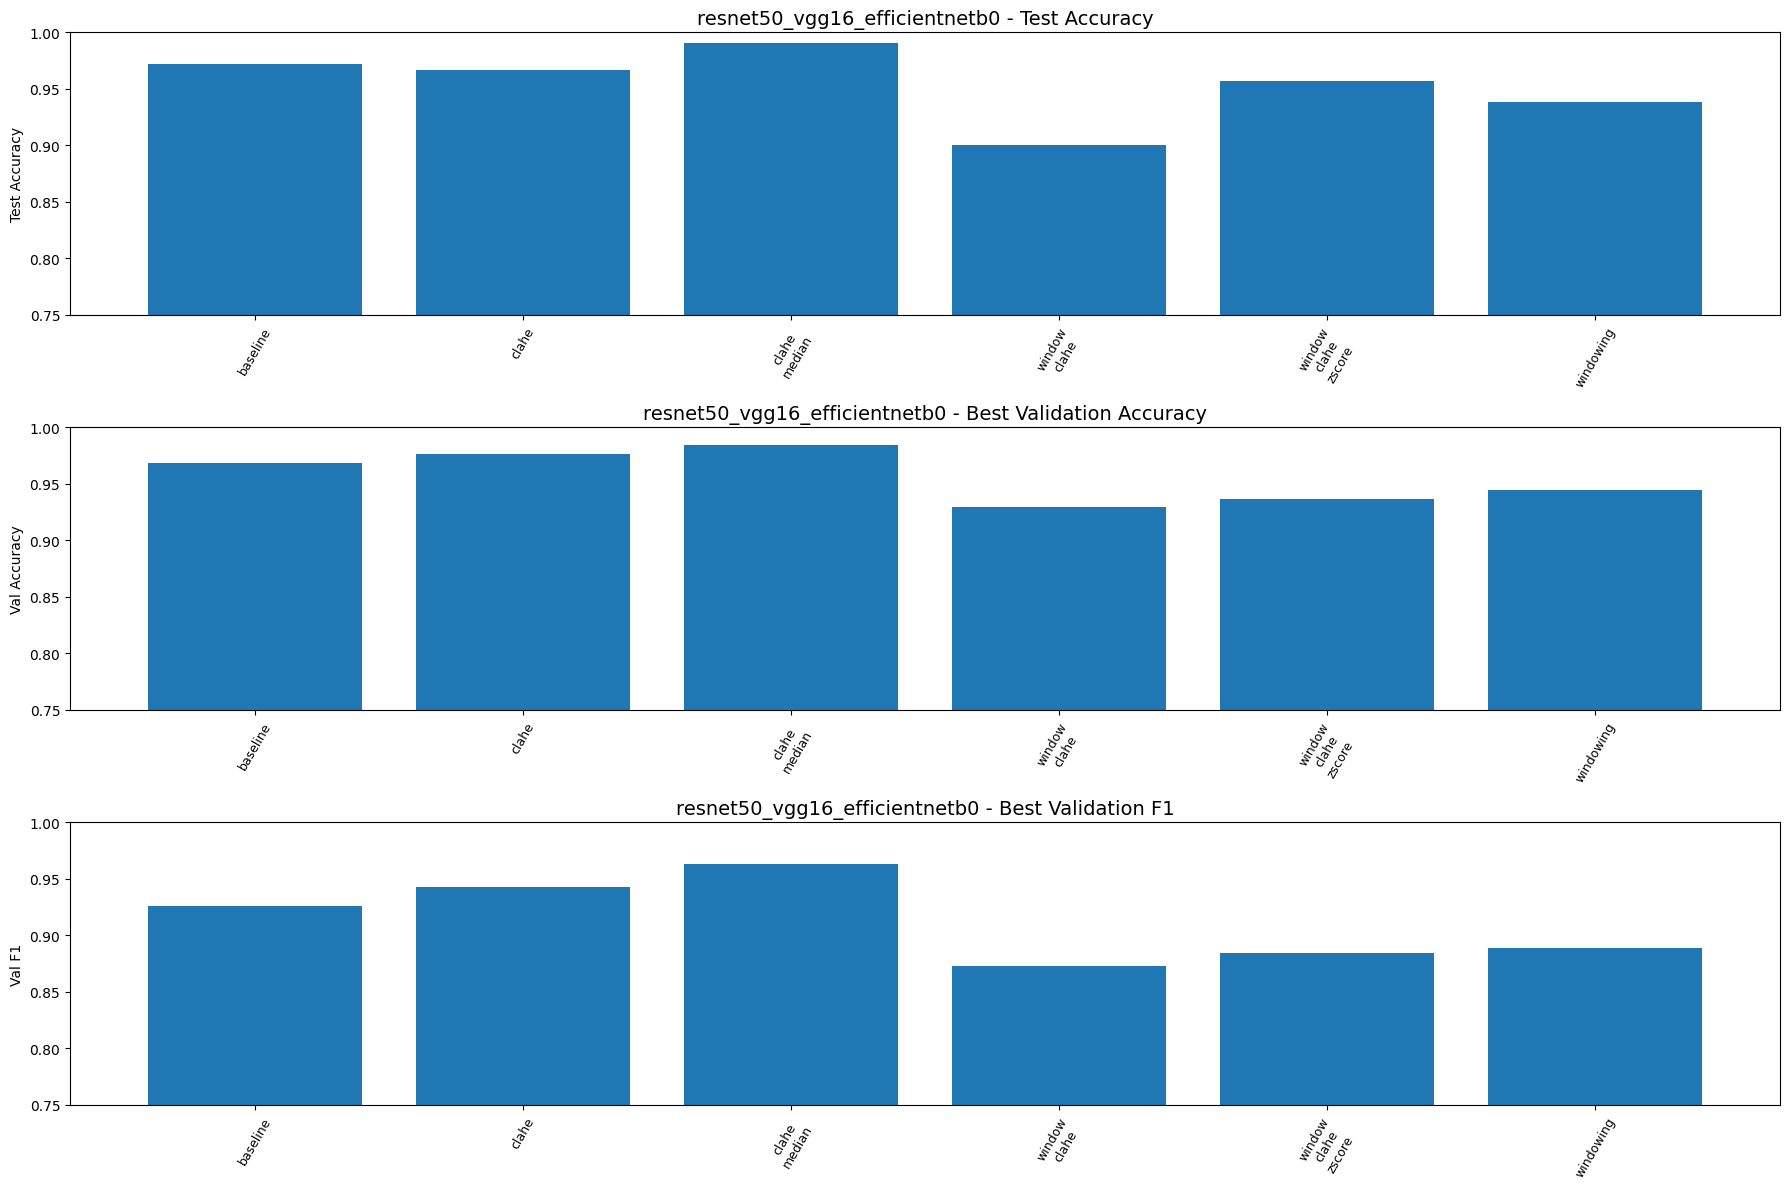

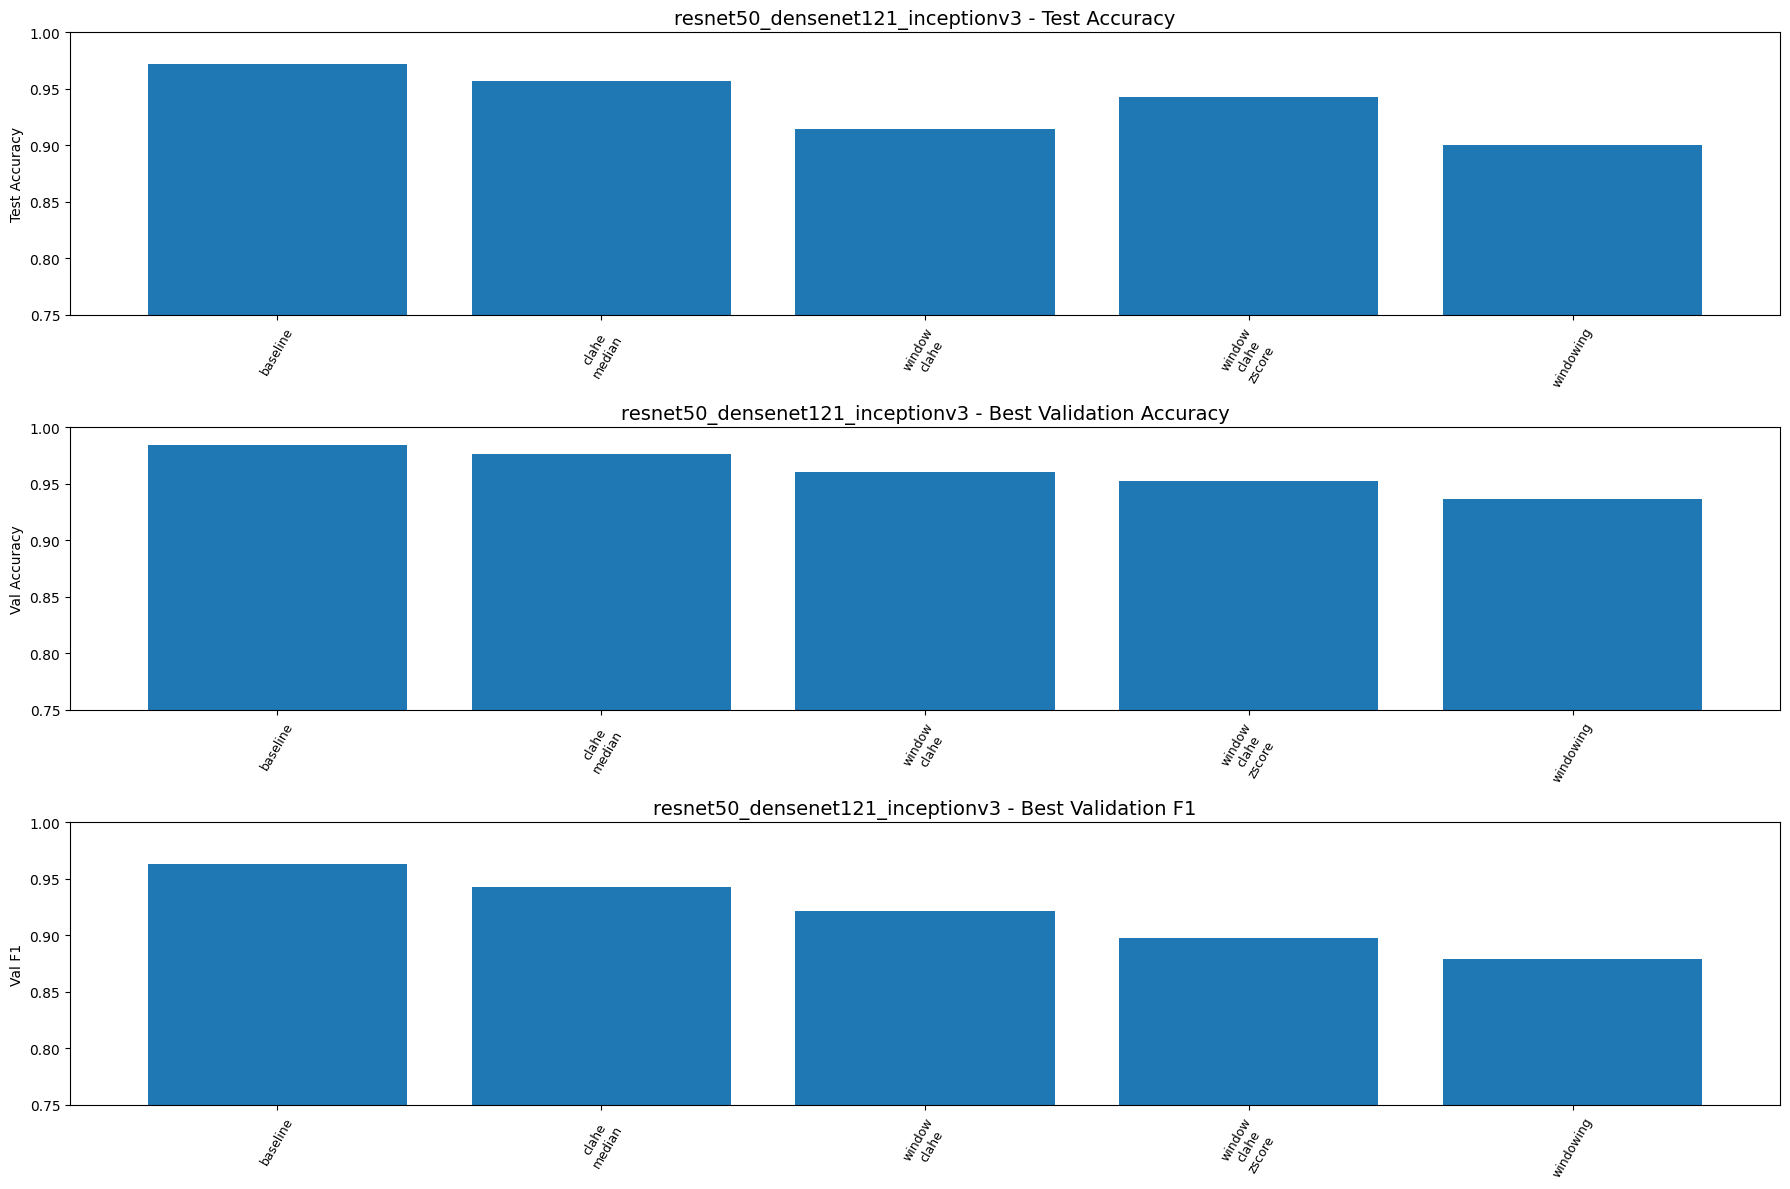

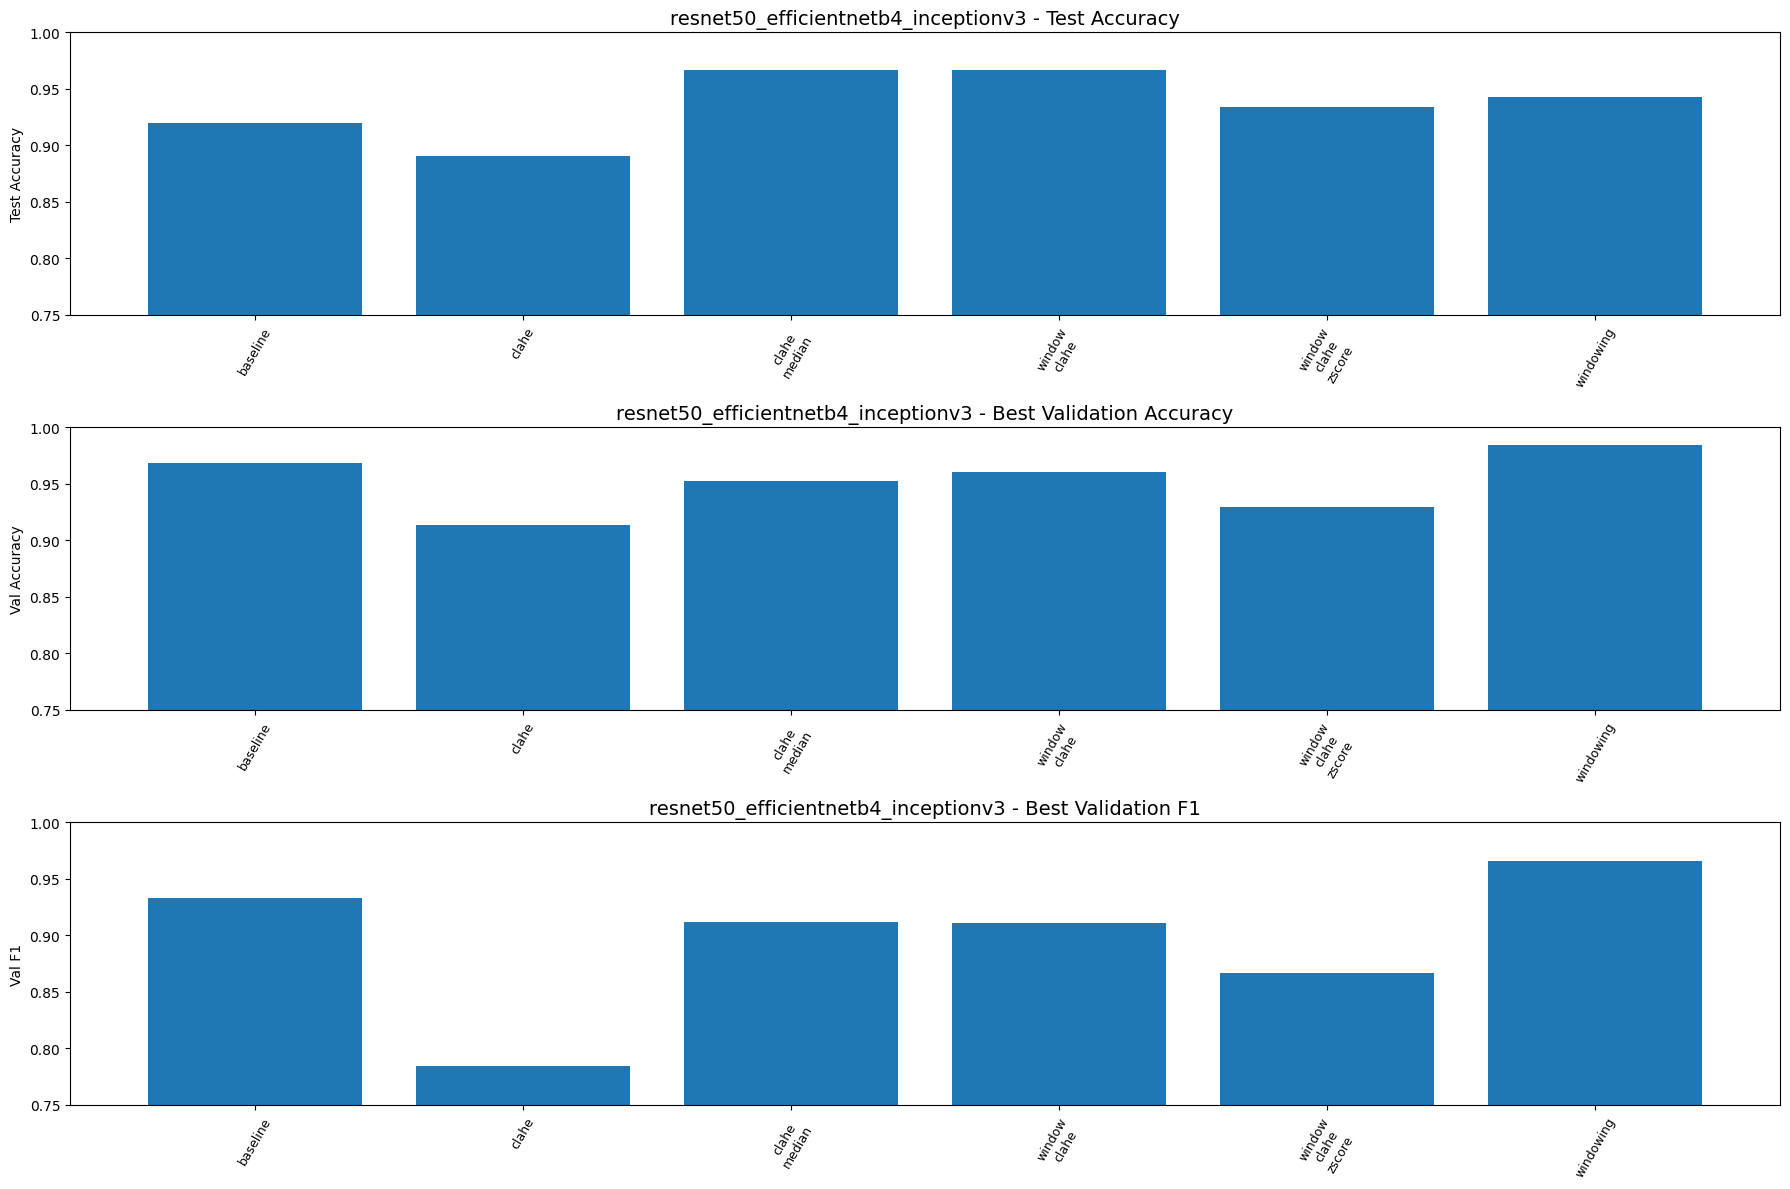

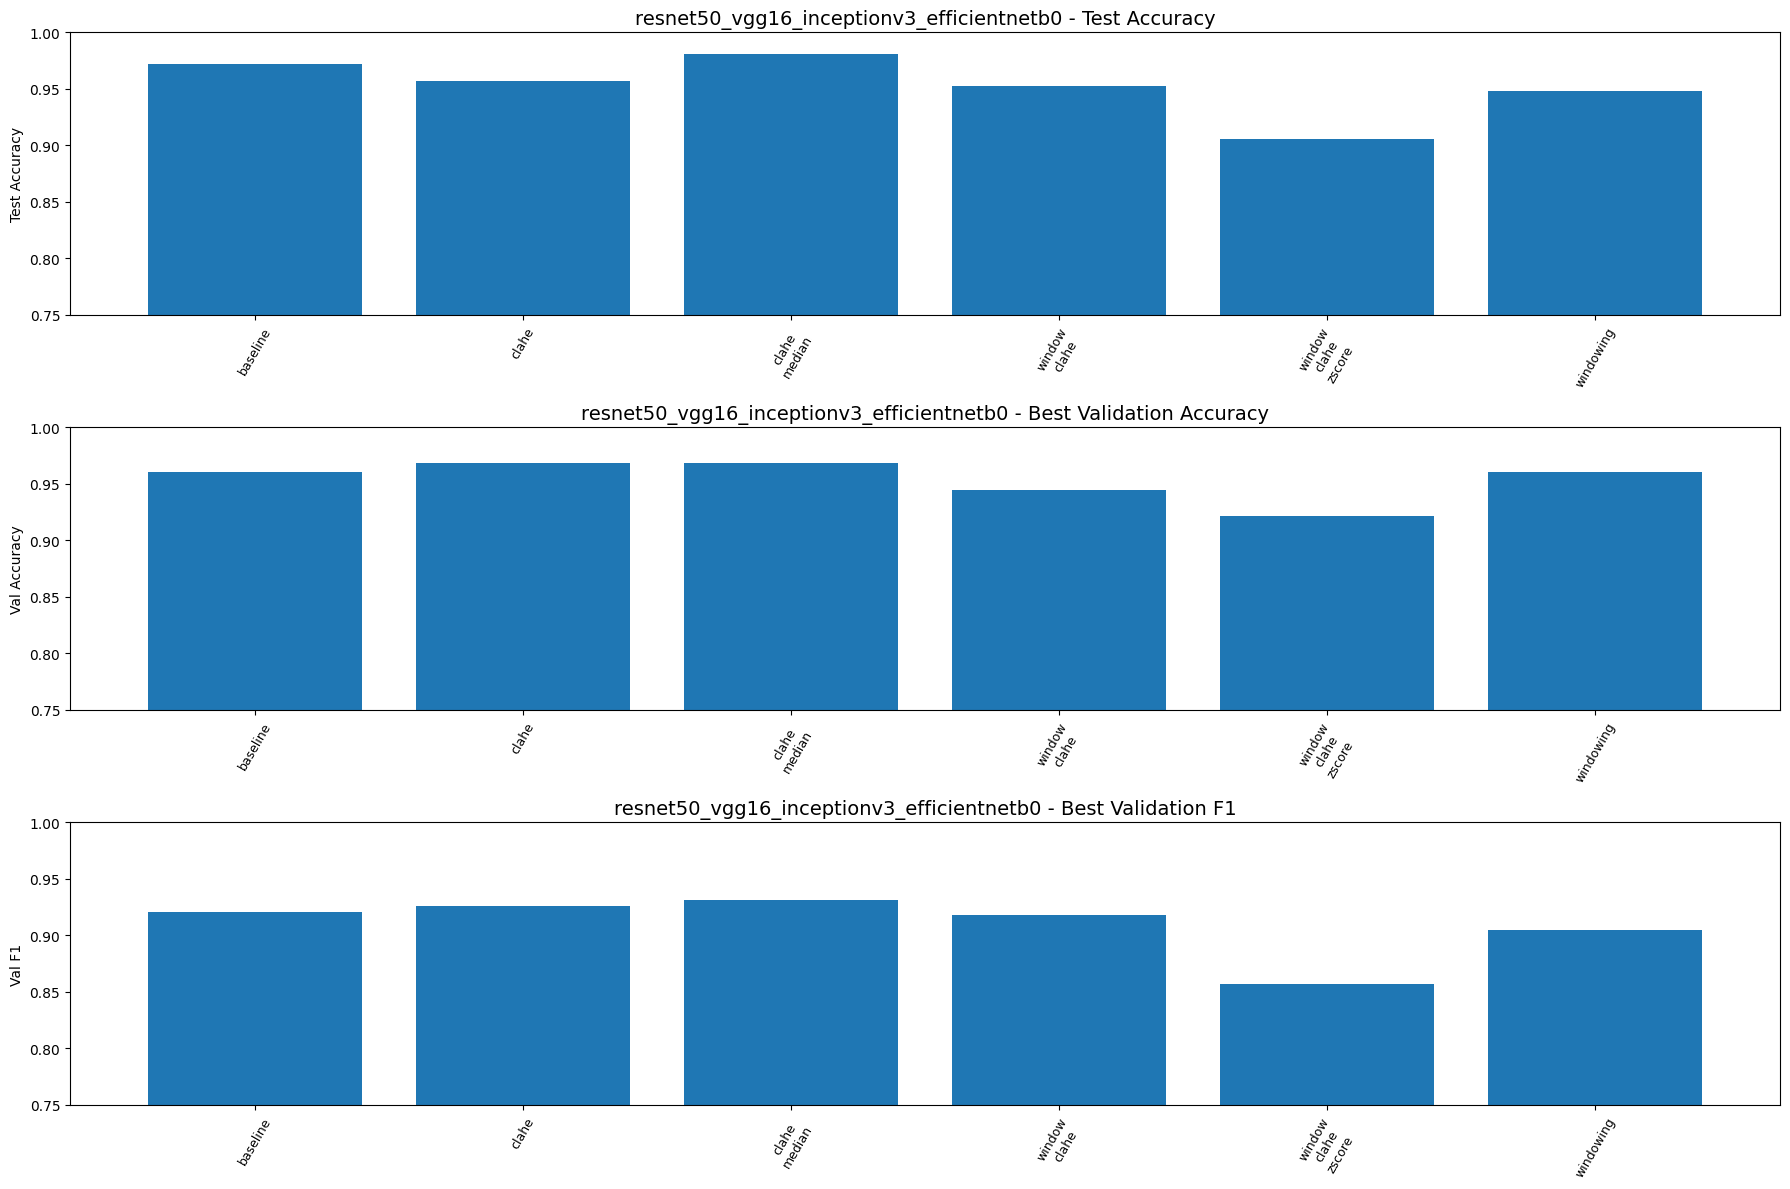

Charts generated successfully!


In [66]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/charts", exist_ok=True)

models = df["hybrid_model"].unique()

for model in models:

    model_df = df[df["hybrid_model"] == model]
    model_df = model_df.sort_values("config")

    # MULTILINE LABELS (fix overlap)
    configs = [c.replace("_", "\n") for c in model_df["config"]]

    # create single figure with 3 charts
    fig, axes = plt.subplots(3, 1, figsize=(18, 12))

    # -------- Test Accuracy --------
    axes[0].bar(configs, model_df["Test_Accuracy"])
    axes[0].set_title(f"{model} - Test Accuracy", fontsize=14)
    axes[0].set_ylabel("Test Accuracy")
    axes[0].set_ylim(0.75, 1)
    axes[0].tick_params(axis='x', rotation=60, labelsize=9)

    # -------- Validation Accuracy --------
    axes[1].bar(configs, model_df["Best_Val_Accuracy"])
    axes[1].set_title(f"{model} - Best Validation Accuracy", fontsize=14)
    axes[1].set_ylabel("Val Accuracy")
    axes[1].set_ylim(0.75, 1)
    axes[1].tick_params(axis='x', rotation=60, labelsize=9)

    # -------- Validation F1 --------
    axes[2].bar(configs, model_df["Best_Val_f1"])
    axes[2].set_title(f"{model} - Best Validation F1", fontsize=14)
    axes[2].set_ylabel("Val F1")
    axes[2].set_ylim(0.75, 1)
    axes[2].tick_params(axis='x', rotation=60, labelsize=9)

    plt.tight_layout()

    plt.show()
    plt.close()

print("Charts generated successfully!")

In [67]:
# Step 1: highest validation F1 per hybrid model
best_configs = df.loc[df.groupby("hybrid_model")["Best_Val_f1"].idxmax()]

# Step 2: if tie, choose lowest validation loss
best_configs = best_configs.loc[
    best_configs.groupby("hybrid_model")["Best_Val_Loss"].idxmin()
]

print(best_configs[["hybrid_model","config","Best_Val_f1","Test_Accuracy"]])

                                 hybrid_model        config  Best_Val_f1  \
7         resnet50_densenet121_efficientnetb4     windowing     0.963030   
18           resnet50_densenet121_inceptionv3      baseline     0.963030   
24        resnet50_efficientnetb4_inceptionv3     windowing     0.965420   
16              resnet50_vgg16_efficientnetb0  clahe_median     0.963030   
0                  resnet50_vgg16_inceptionv3      baseline     0.942480   
33  resnet50_vgg16_inceptionv3_efficientnetb0  clahe_median     0.930839   

    Test_Accuracy  
7        0.947867  
18       0.971564  
24       0.943128  
16       0.990521  
0        0.947867  
33       0.981043  


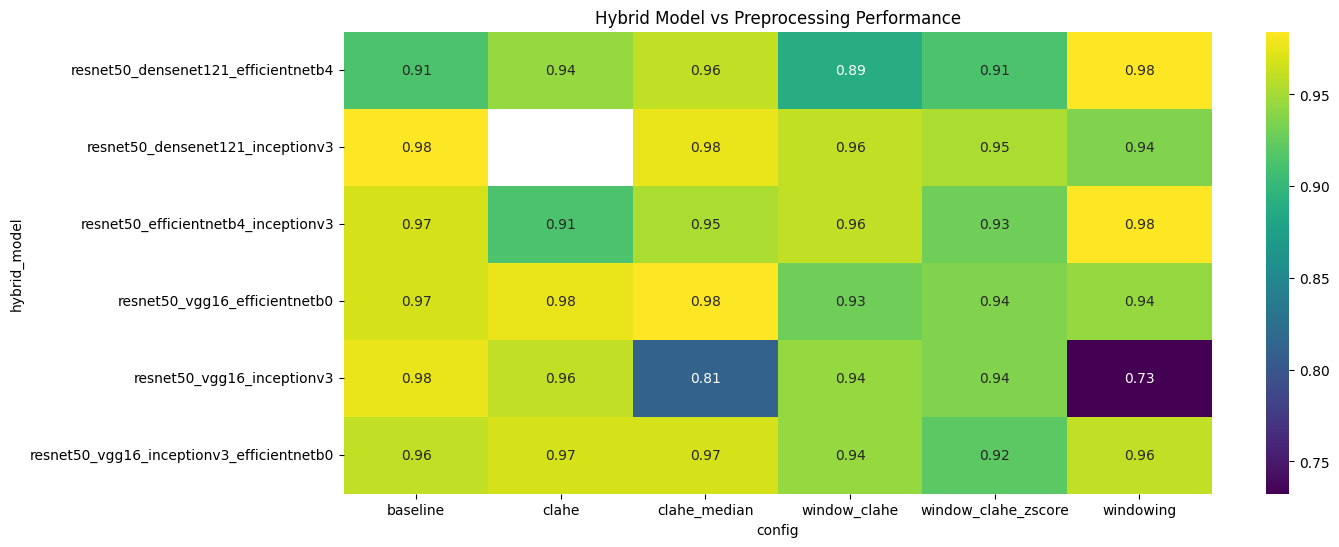

In [68]:
import seaborn as sns

pivot = df.pivot(index="hybrid_model", columns="config", values="Best_Val_Accuracy")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Hybrid Model vs Preprocessing Performance")
plt.show()

['resnet50\ndensenet121\nefficientnetb4', 'resnet50\ndensenet121\ninceptionv3', 'resnet50\nefficientnetb4\ninceptionv3', 'resnet50\nvgg16\nefficientnetb0', 'resnet50\nvgg16\ninceptionv3', 'resnet50\nvgg16\ninceptionv3\nefficientnetb0']


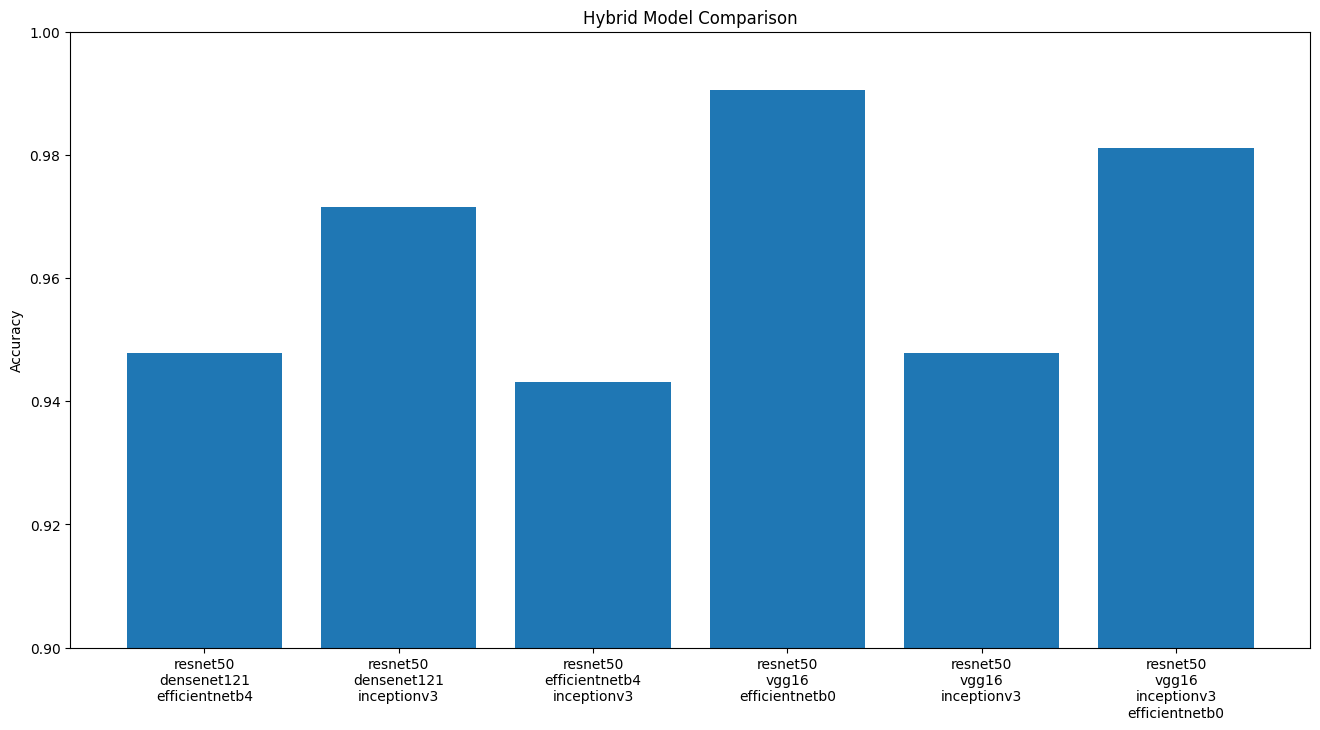

In [ ]:
best_models = df.loc[df.groupby("hybrid_model")["Best_Val_f1"].idxmax()]
# print(best_models)
os.makedirs("results/charts/comparison",exist_ok=True)
config = [c.replace("_", "\n") for c in best_models["hybrid_model"]]
print(config)

plt.figure(figsize=(16,8))
plt.bar(config, best_models["Best_Val_f1"])
plt.xticks(rotation=0)
plt.ylabel("Best Val F1")
plt.ylim(0.90,1)
plt.savefig("results/charts/comparison/hybrid_model_comparison.png")
plt.title("Hybrid Model Comparison")
plt.show()

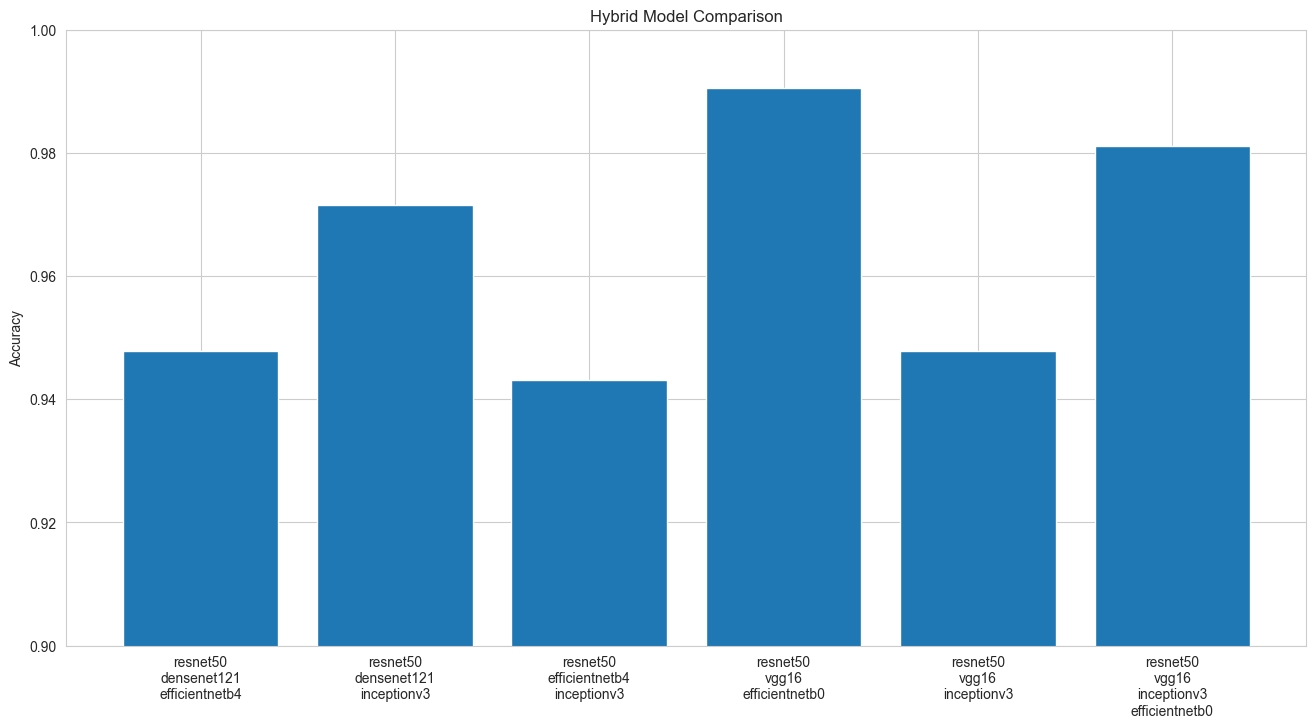

In [81]:
# ensure numeric
df["Best_Val_f1"] = pd.to_numeric(df["Best_Val_f1"], errors="coerce")

# remove invalid hybrids
df = df[df["hybrid_model"].notna()]
df = df[df["hybrid_model"].apply(lambda x: len(x.split("_")) >= 3)]

# sort descending
df = df.sort_values(by="Best_Val_f1", ascending=False)

# pick best per hybrid
best_models = df.groupby("hybrid_model", as_index=False).first()

# plotting
import os
os.makedirs("results/charts/comparison", exist_ok=True)

config = [c.replace("_", "\n") for c in best_models["hybrid_model"]]

plt.figure(figsize=(16,8))
plt.bar(config, best_models["Test_Accuracy"])
plt.ylabel("Accuracy")
plt.ylim(0.90, 1)
plt.title("Hybrid Model Comparison")
plt.xticks(rotation=0)
plt.savefig("results/charts/comparison/hybrid_model_accuracy_comparison.png")
plt.show()

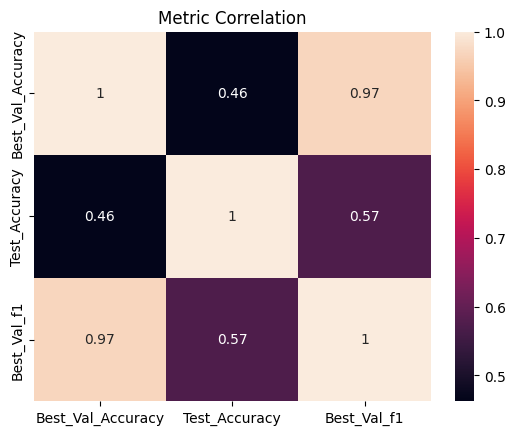

In [75]:
import seaborn as sns

corr = df[["Best_Val_Accuracy","Test_Accuracy","Best_Val_f1"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Metric Correlation")
plt.show()

In [76]:
config_perf = df.groupby("config")["Best_Val_f1"].mean().sort_values(ascending=False)

print(config_perf)

config
baseline               0.917302
clahe                  0.889356
window_clahe           0.886693
clahe_median           0.873052
window_clahe_zscore    0.869643
windowing              0.863960
Name: Best_Val_f1, dtype: float64


In [77]:
df["score"] = df["Best_Val_f1"] * 0.7 + df["Test_Accuracy"] * 0.3

best_configs = df.loc[df.groupby("hybrid_model")["score"].idxmax()]

In [78]:
best_configs

,Model,Test_Accuracy,Best_Val_Accuracy,Best_Val_f1,Best_Val_Loss,Precision,Recall,F1,Epochs,prep_windowing,prep_clahe,prep_median,prep_norm_type,hybrid_model,config,epoch,hybrid_model_list,score
7,resnet50_densenet121_efficientnetb4_windowing_...,0.947867,0.984252,0.963030,0.083120,0.947958,0.947867,0.947557,100,True,NaN,NaN,NaN,resnet50_densenet121_efficientnetb4,windowing,100,"[resnet50, densenet121, efficientnetb4]",0.958481
18,resnet50_densenet121_inceptionv3_baseline_ep100,0.971564,0.984252,0.963030,0.087574,0.973169,0.971564,0.972157,100,NaN,NaN,NaN,NaN,resnet50_densenet121_inceptionv3,baseline,100,"[resnet50, densenet121, inceptionv3]",0.965590
24,resnet50_efficientnetb4_inceptionv3_windowing_...,0.943128,0.984252,0.965420,0.064220,0.959913,0.943128,0.947271,100,True,NaN,NaN,NaN,resnet50_efficientnetb4_inceptionv3,windowing,100,"[resnet50, efficientnetb4, inceptionv3]",0.958732
16,resnet50_vgg16_efficientnetb0_clahe_median_ep100,0.990521,0.984252,0.963030,0.091196,0.990747,0.990521,0.990568,100,NaN,True,True,NaN,resnet50_vgg16_efficientnetb0,clahe_median,100,"[resnet50, vgg16, efficientnetb0]",0.971278
0,resnet50_vgg16_inceptionv3_baseline_ep100,0.947867,0.976378,0.942480,0.121789,0.954101,0.947867,0.946740,100,NaN,NaN,NaN,NaN,resnet50_vgg16_inceptionv3,baseline,100,"[resnet50, vgg16, inceptionv3]",0.944096
33,resnet50_vgg16_inceptionv3_efficientnetb0_clah...,0.981043,0.968504,0.930839,0.140075,0.981043,0.981043,0.981043,100,NaN,True,True,NaN,resnet50_vgg16_inceptionv3_efficientnetb0,clahe_median,100,"[resnet50, vgg16, inceptionv3, efficientnetb0]",0.945900


C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


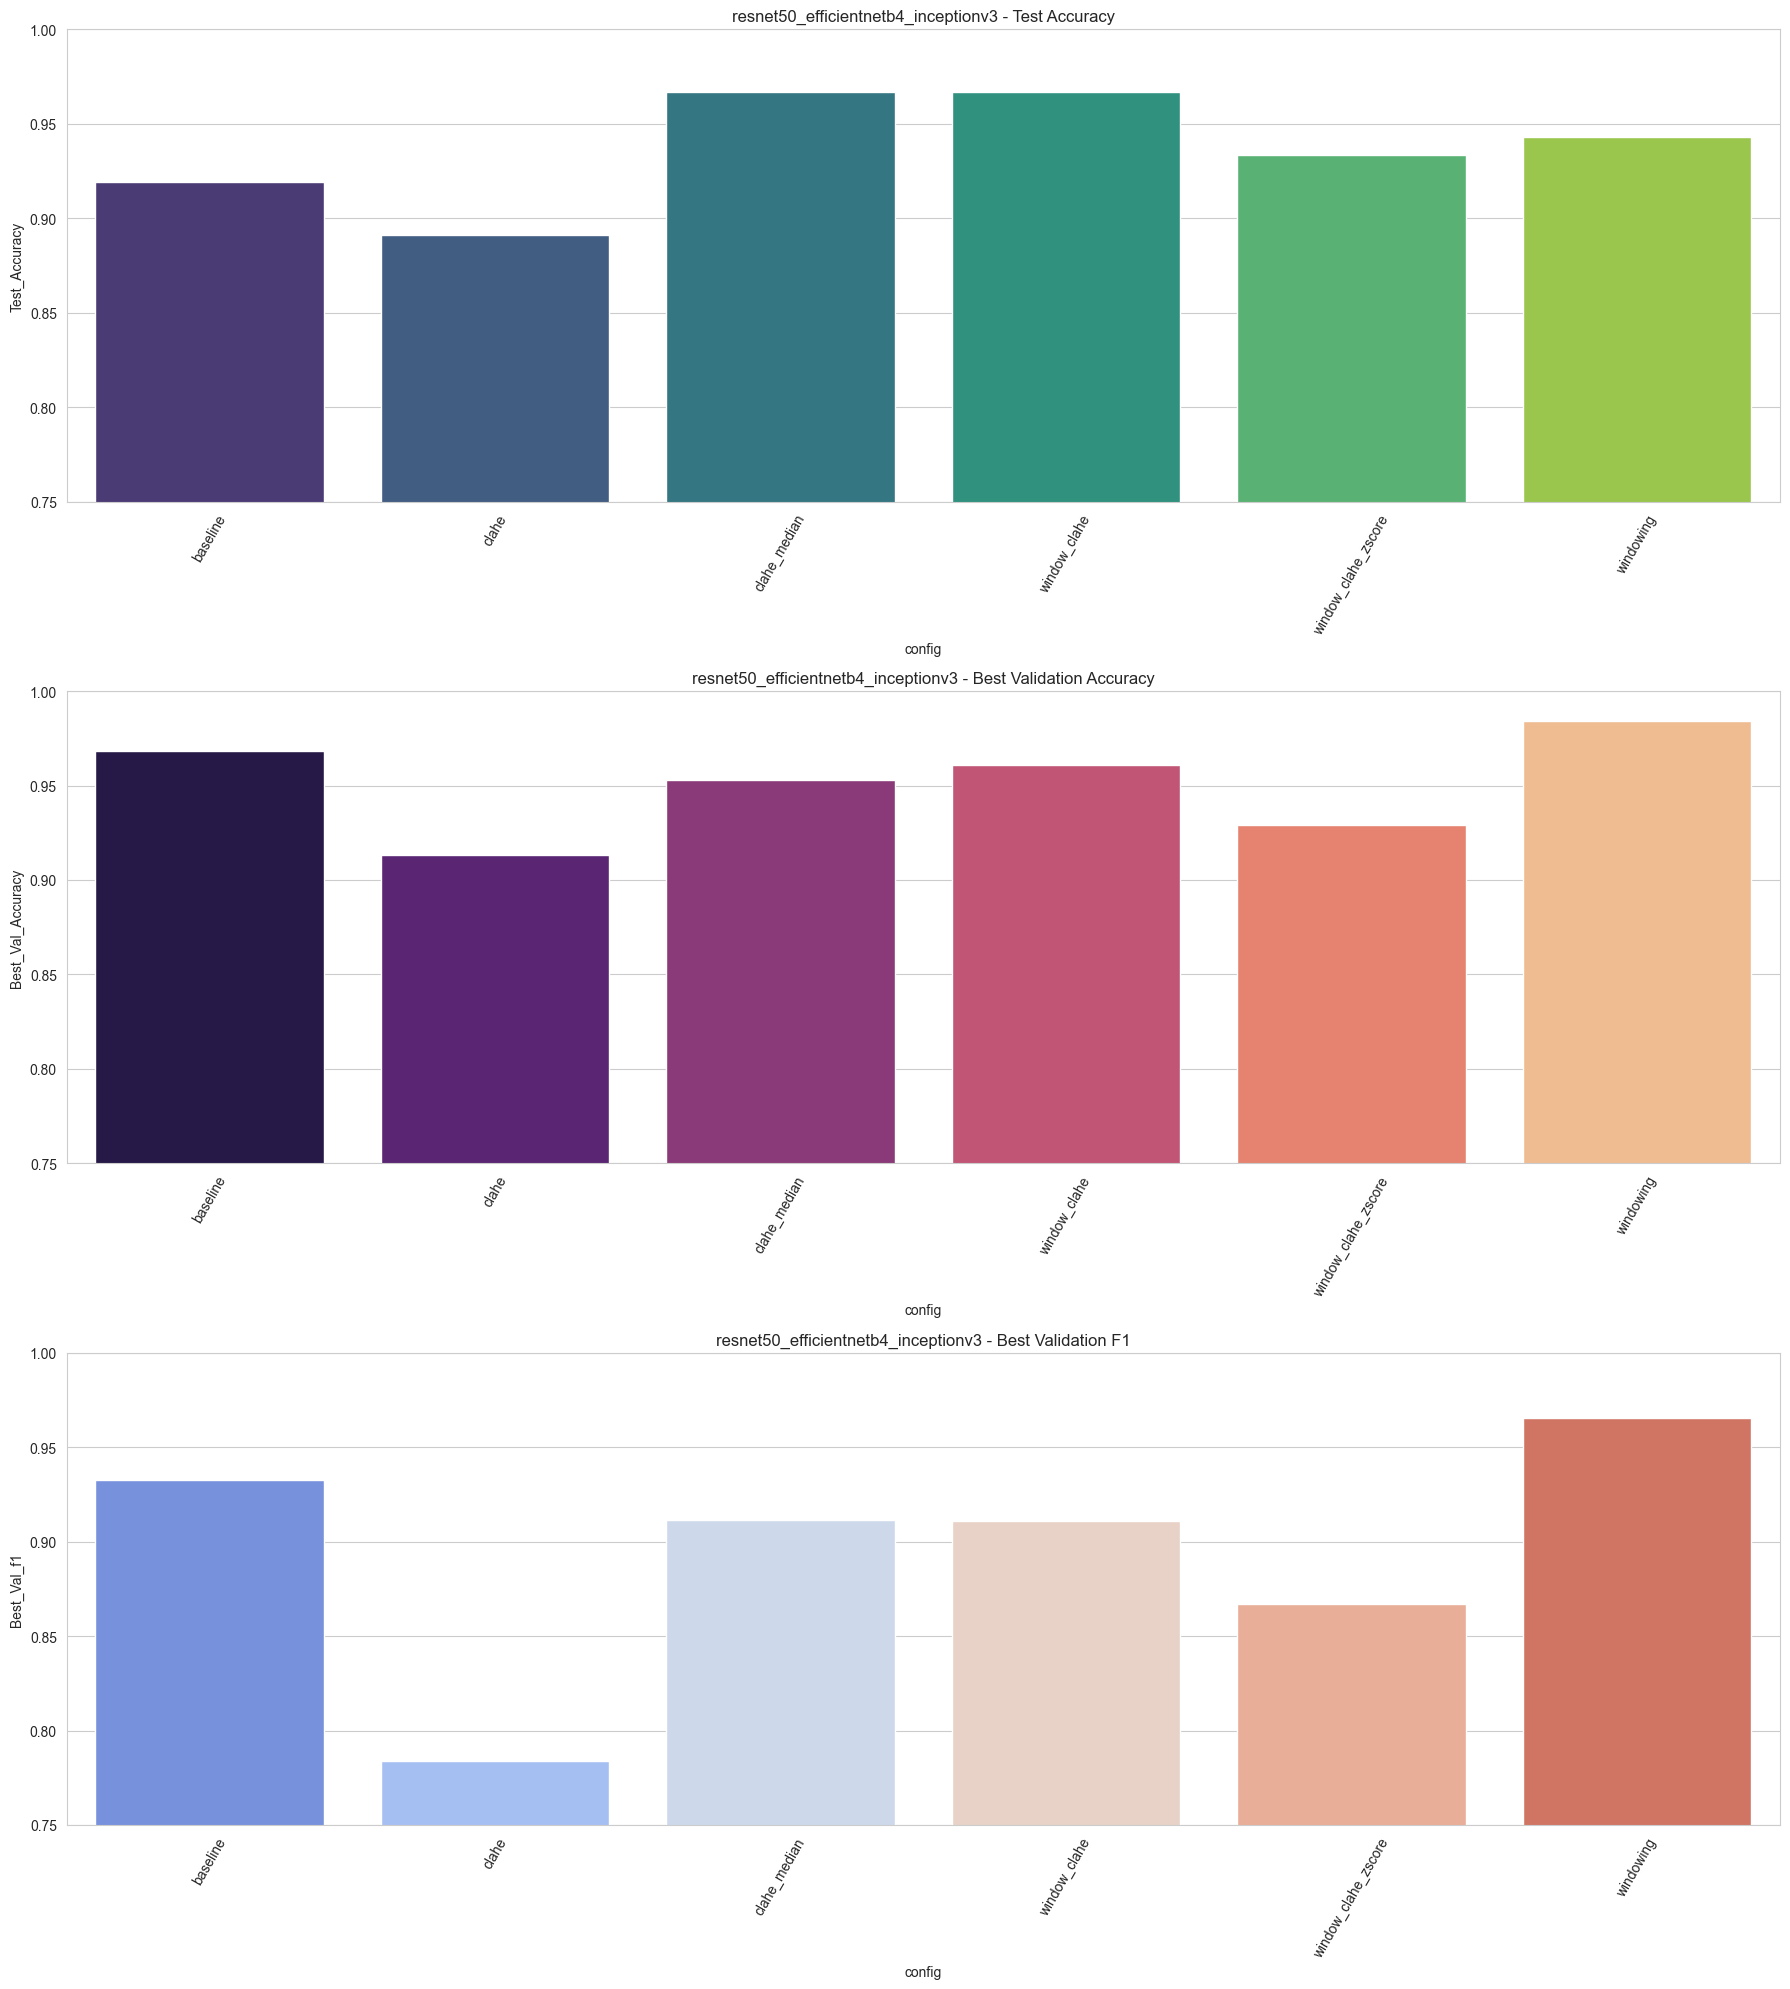

C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


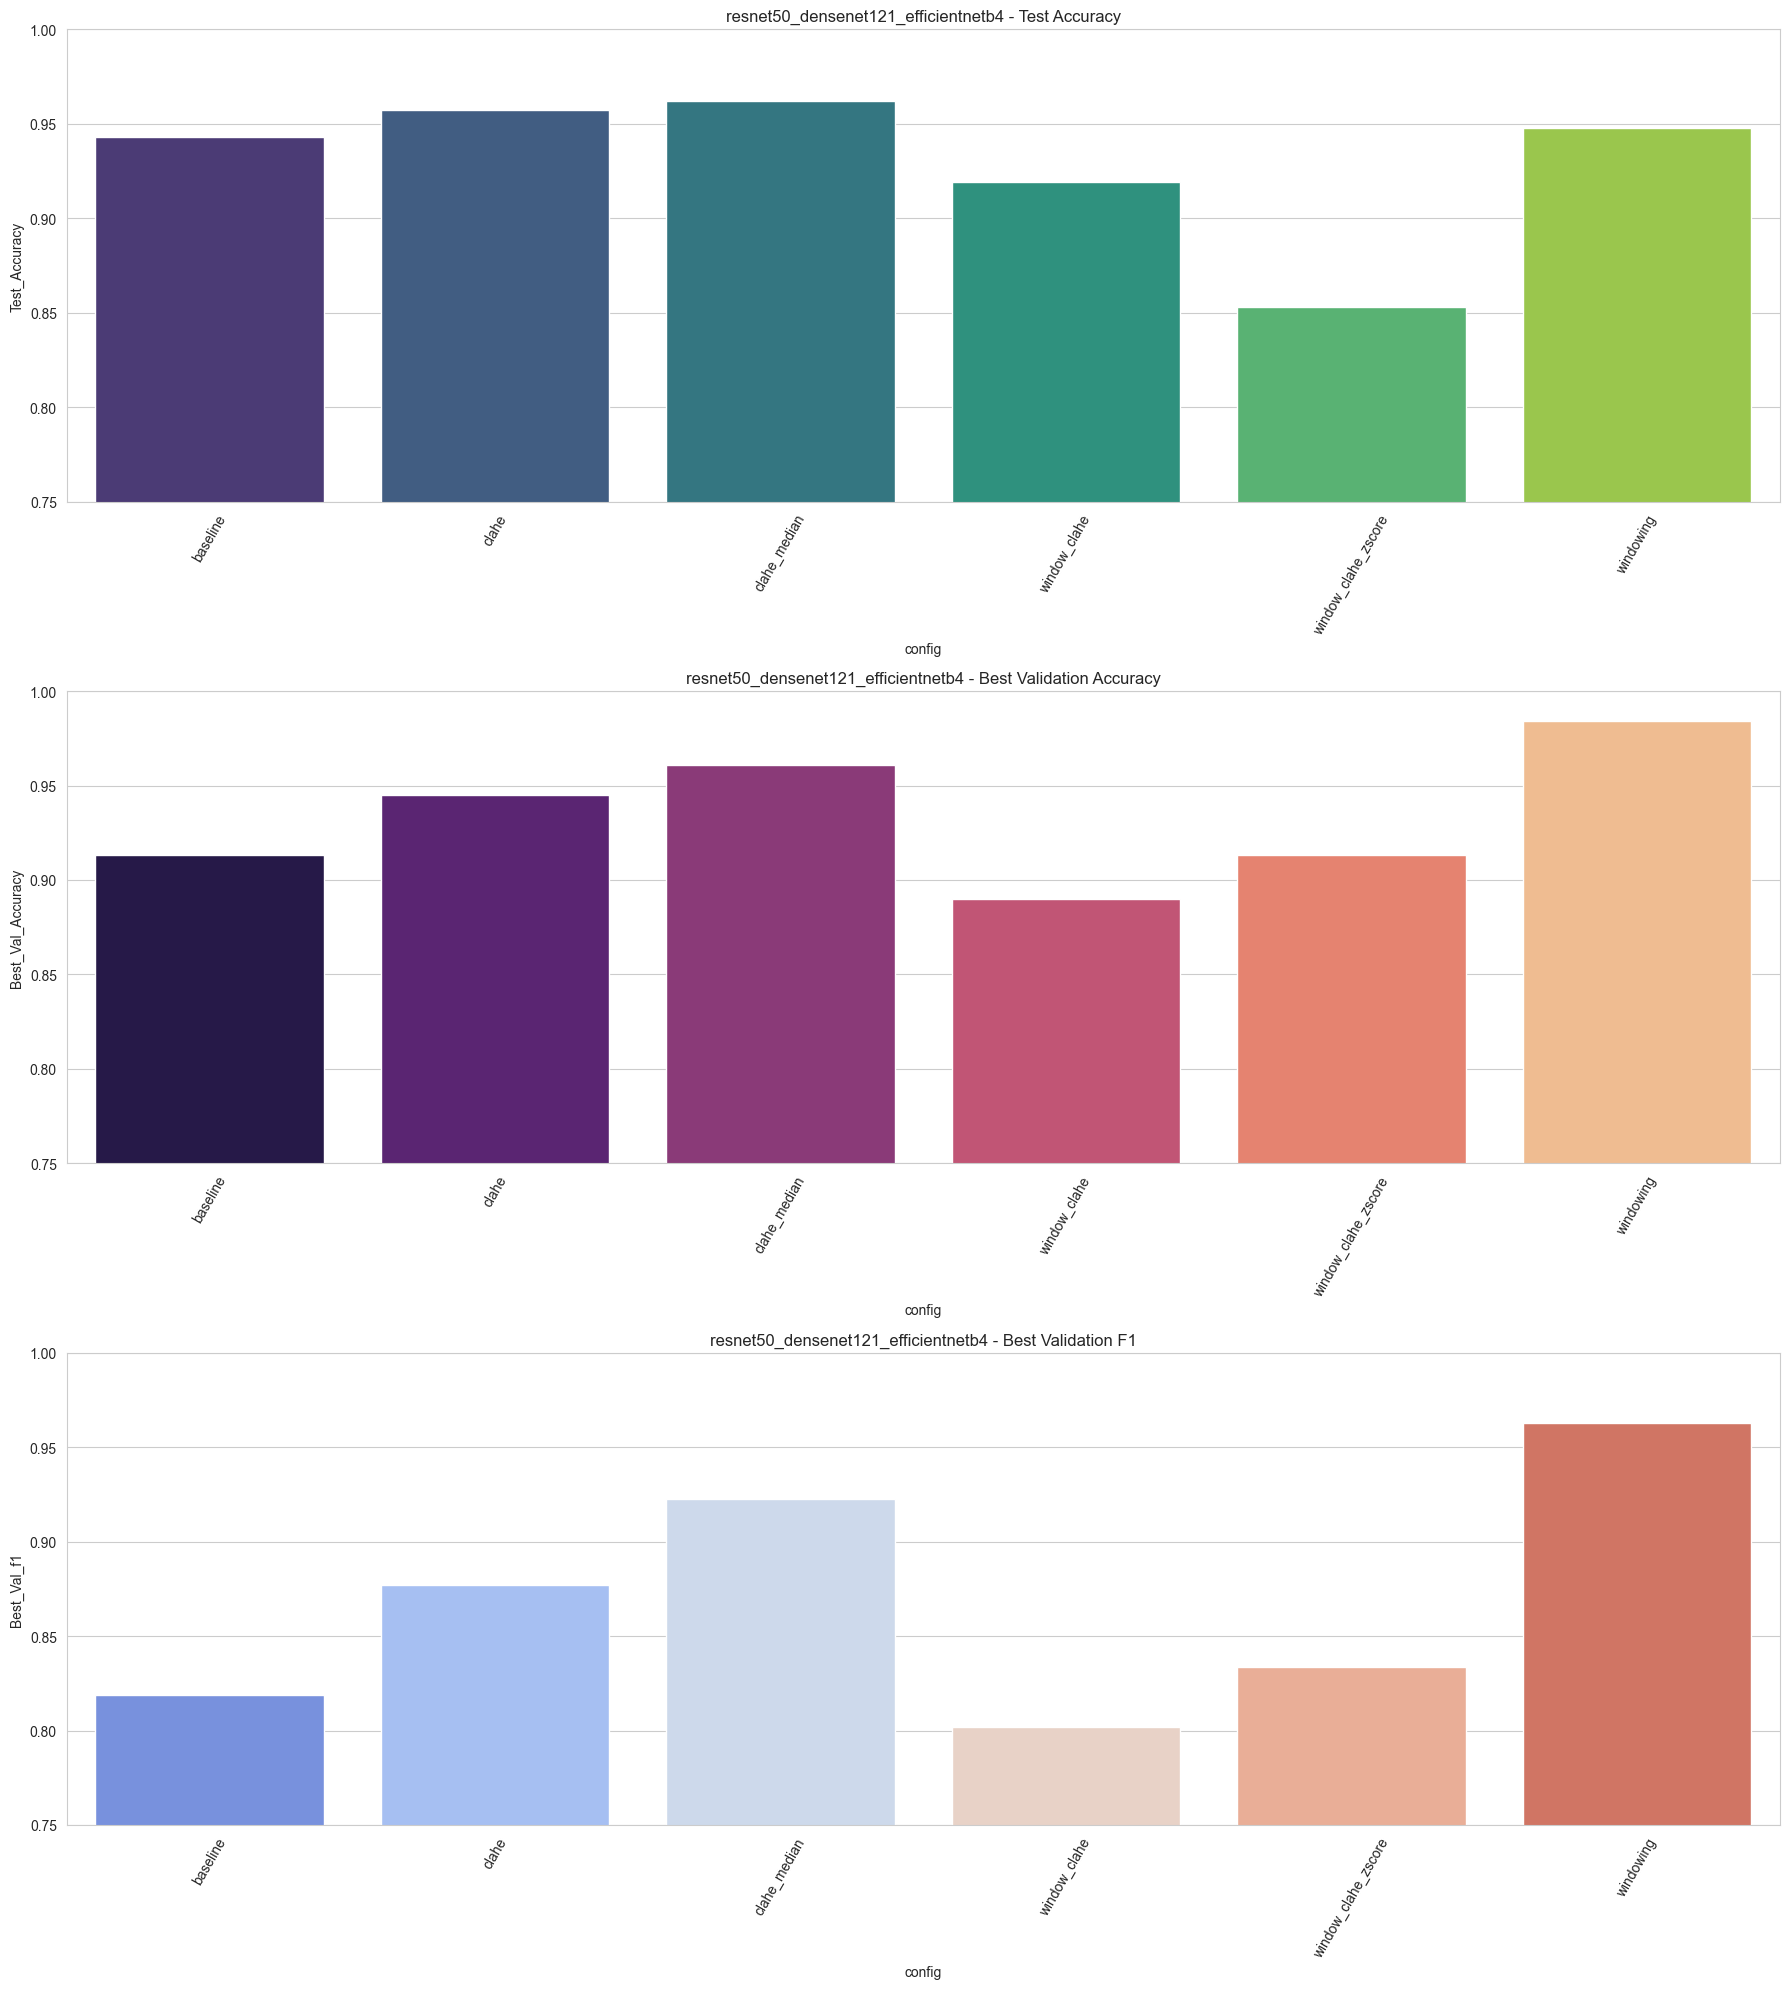

C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


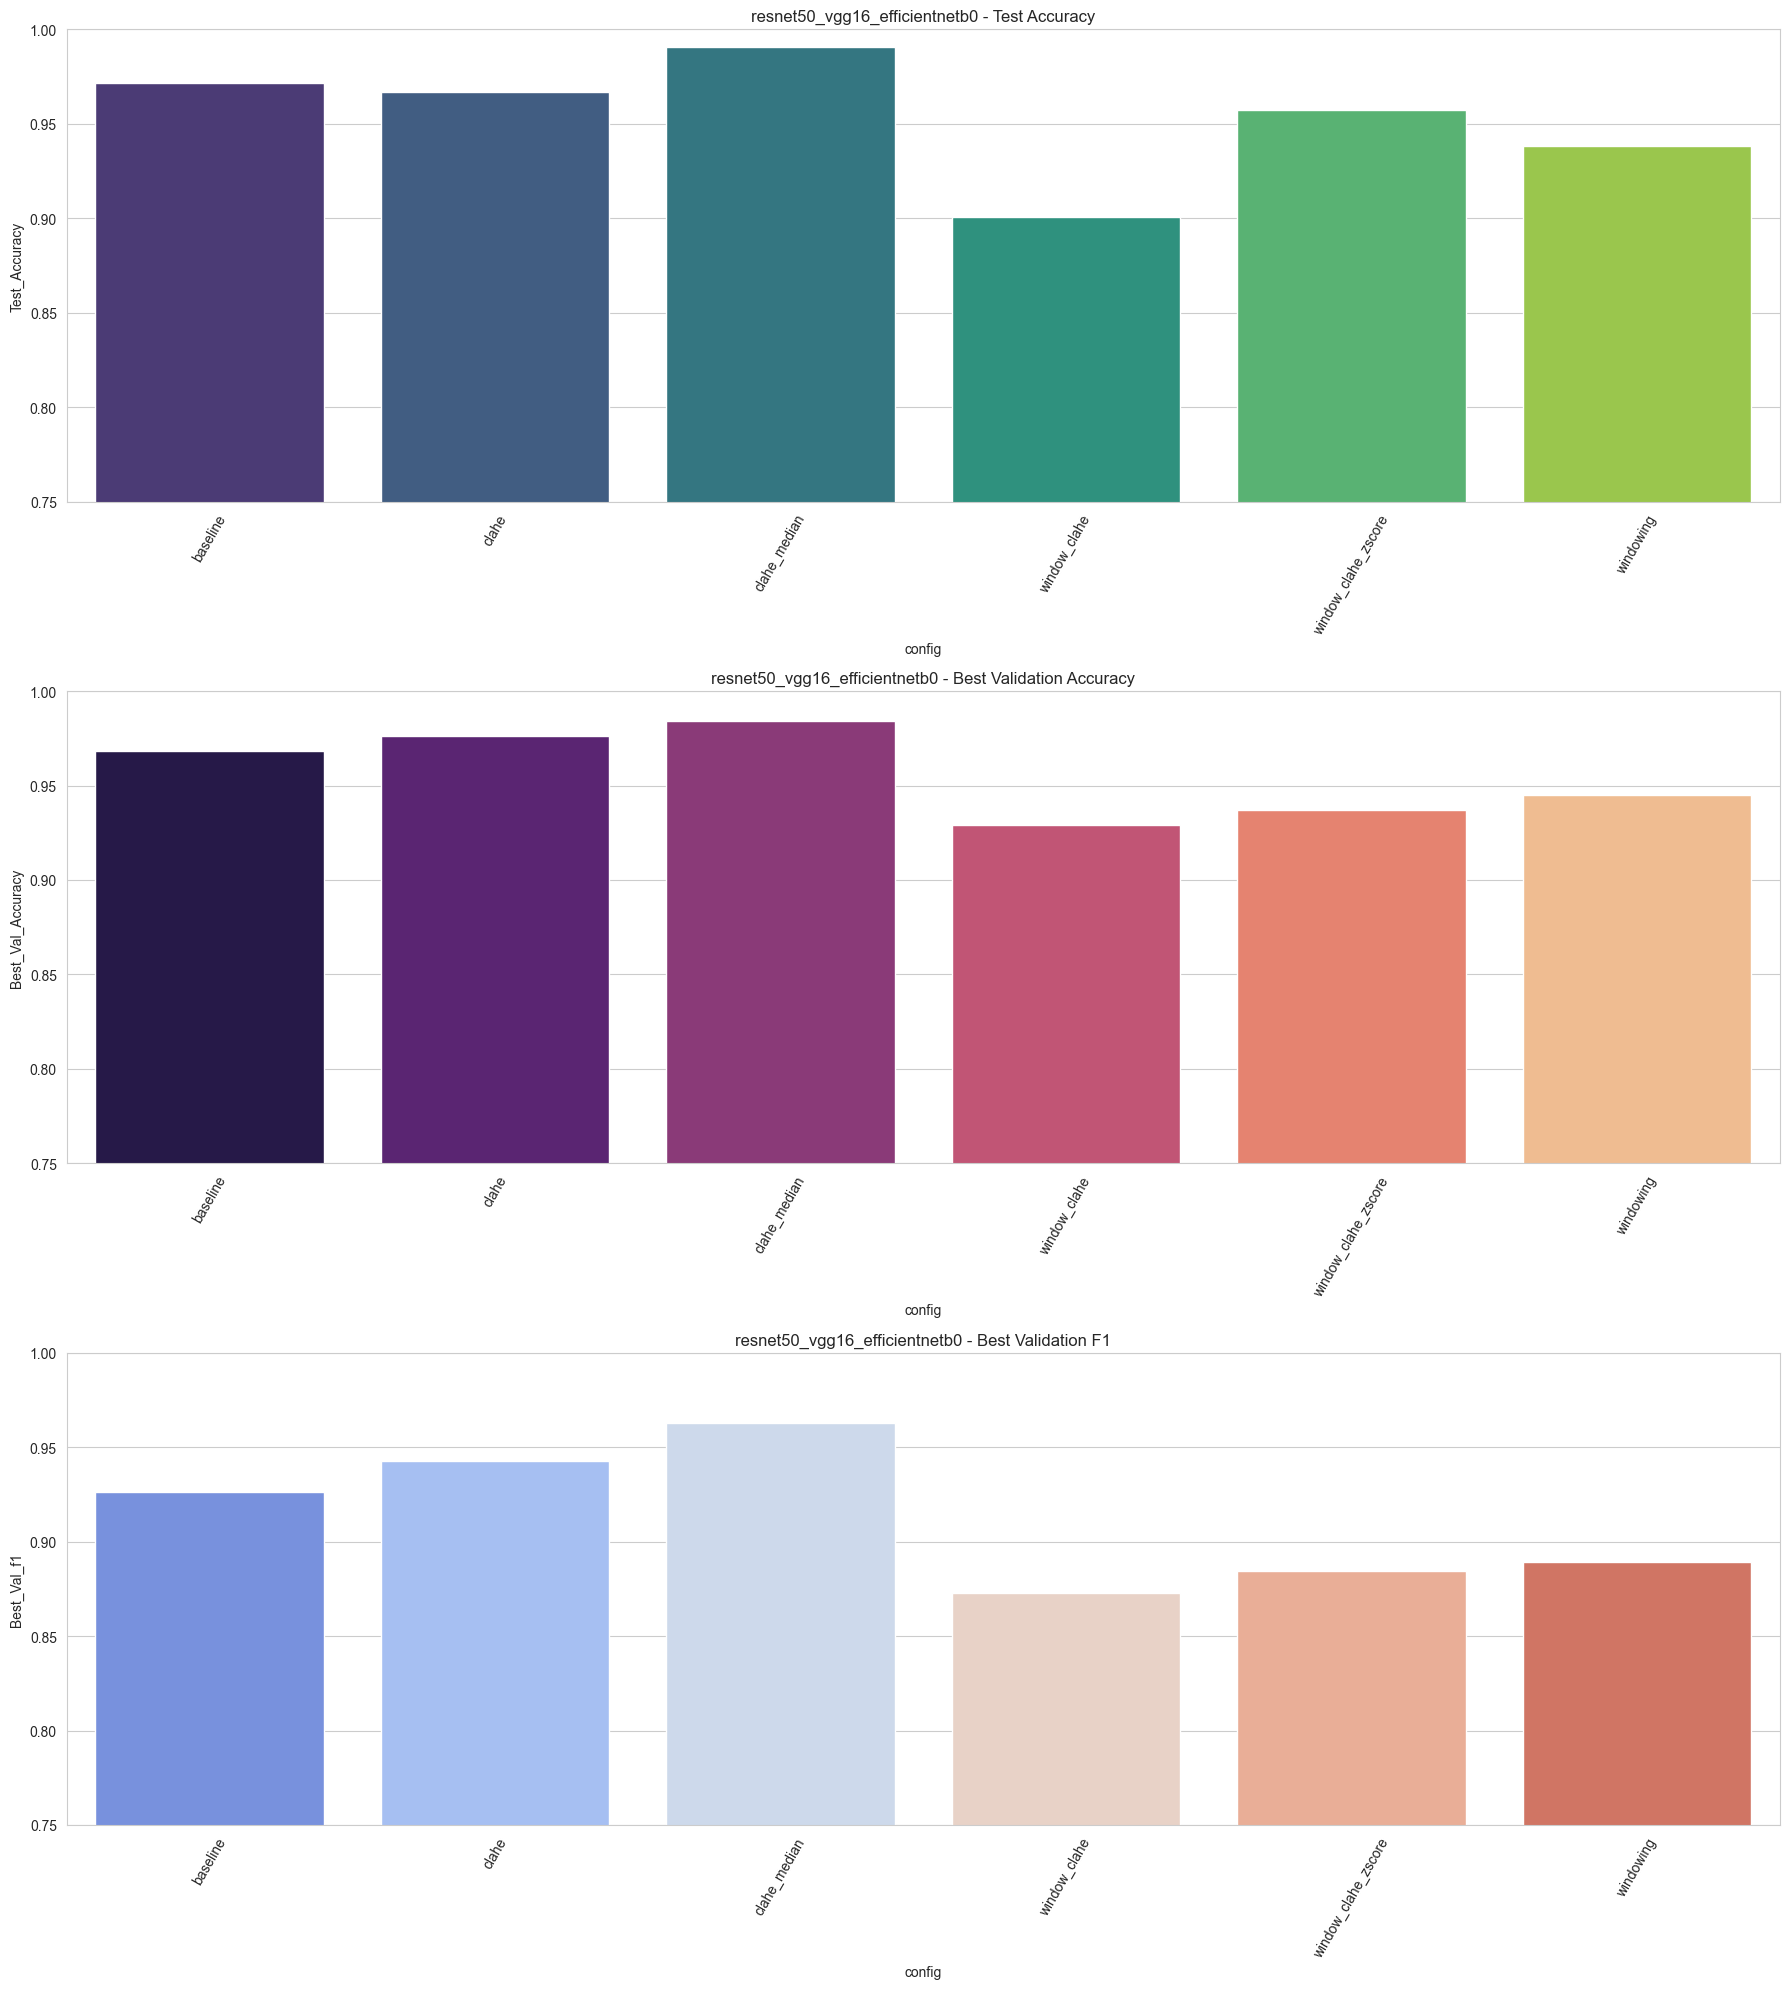

C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


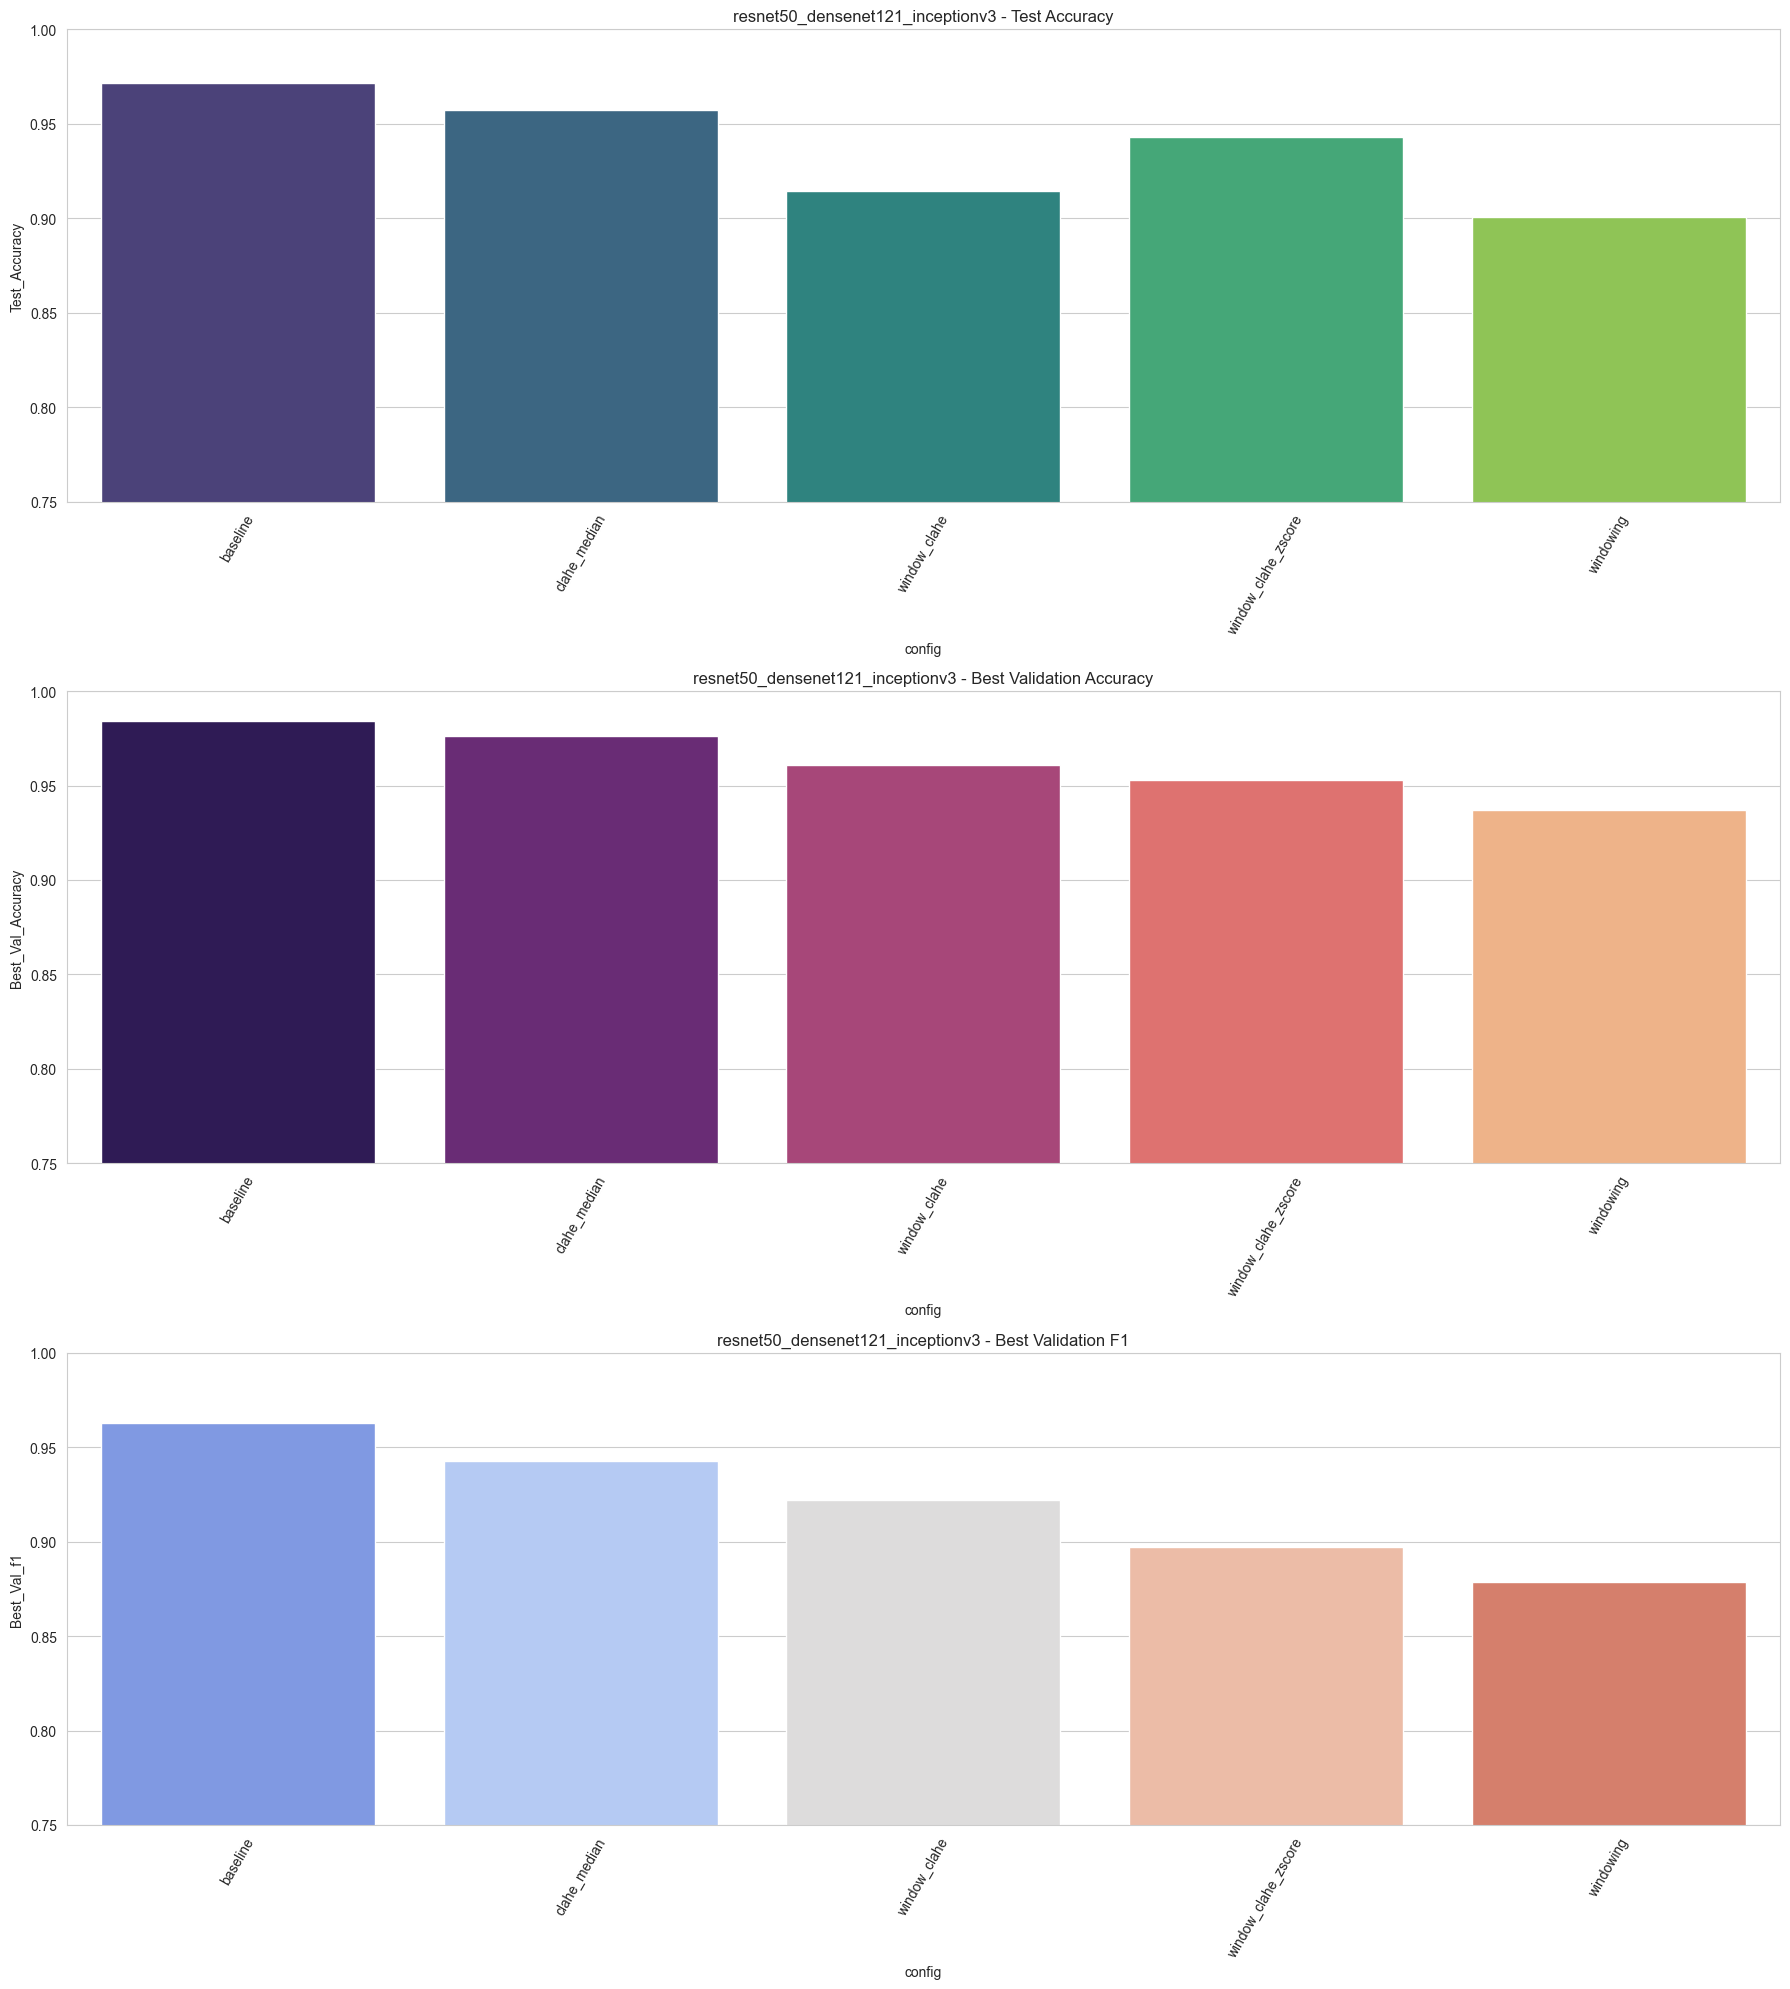

C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


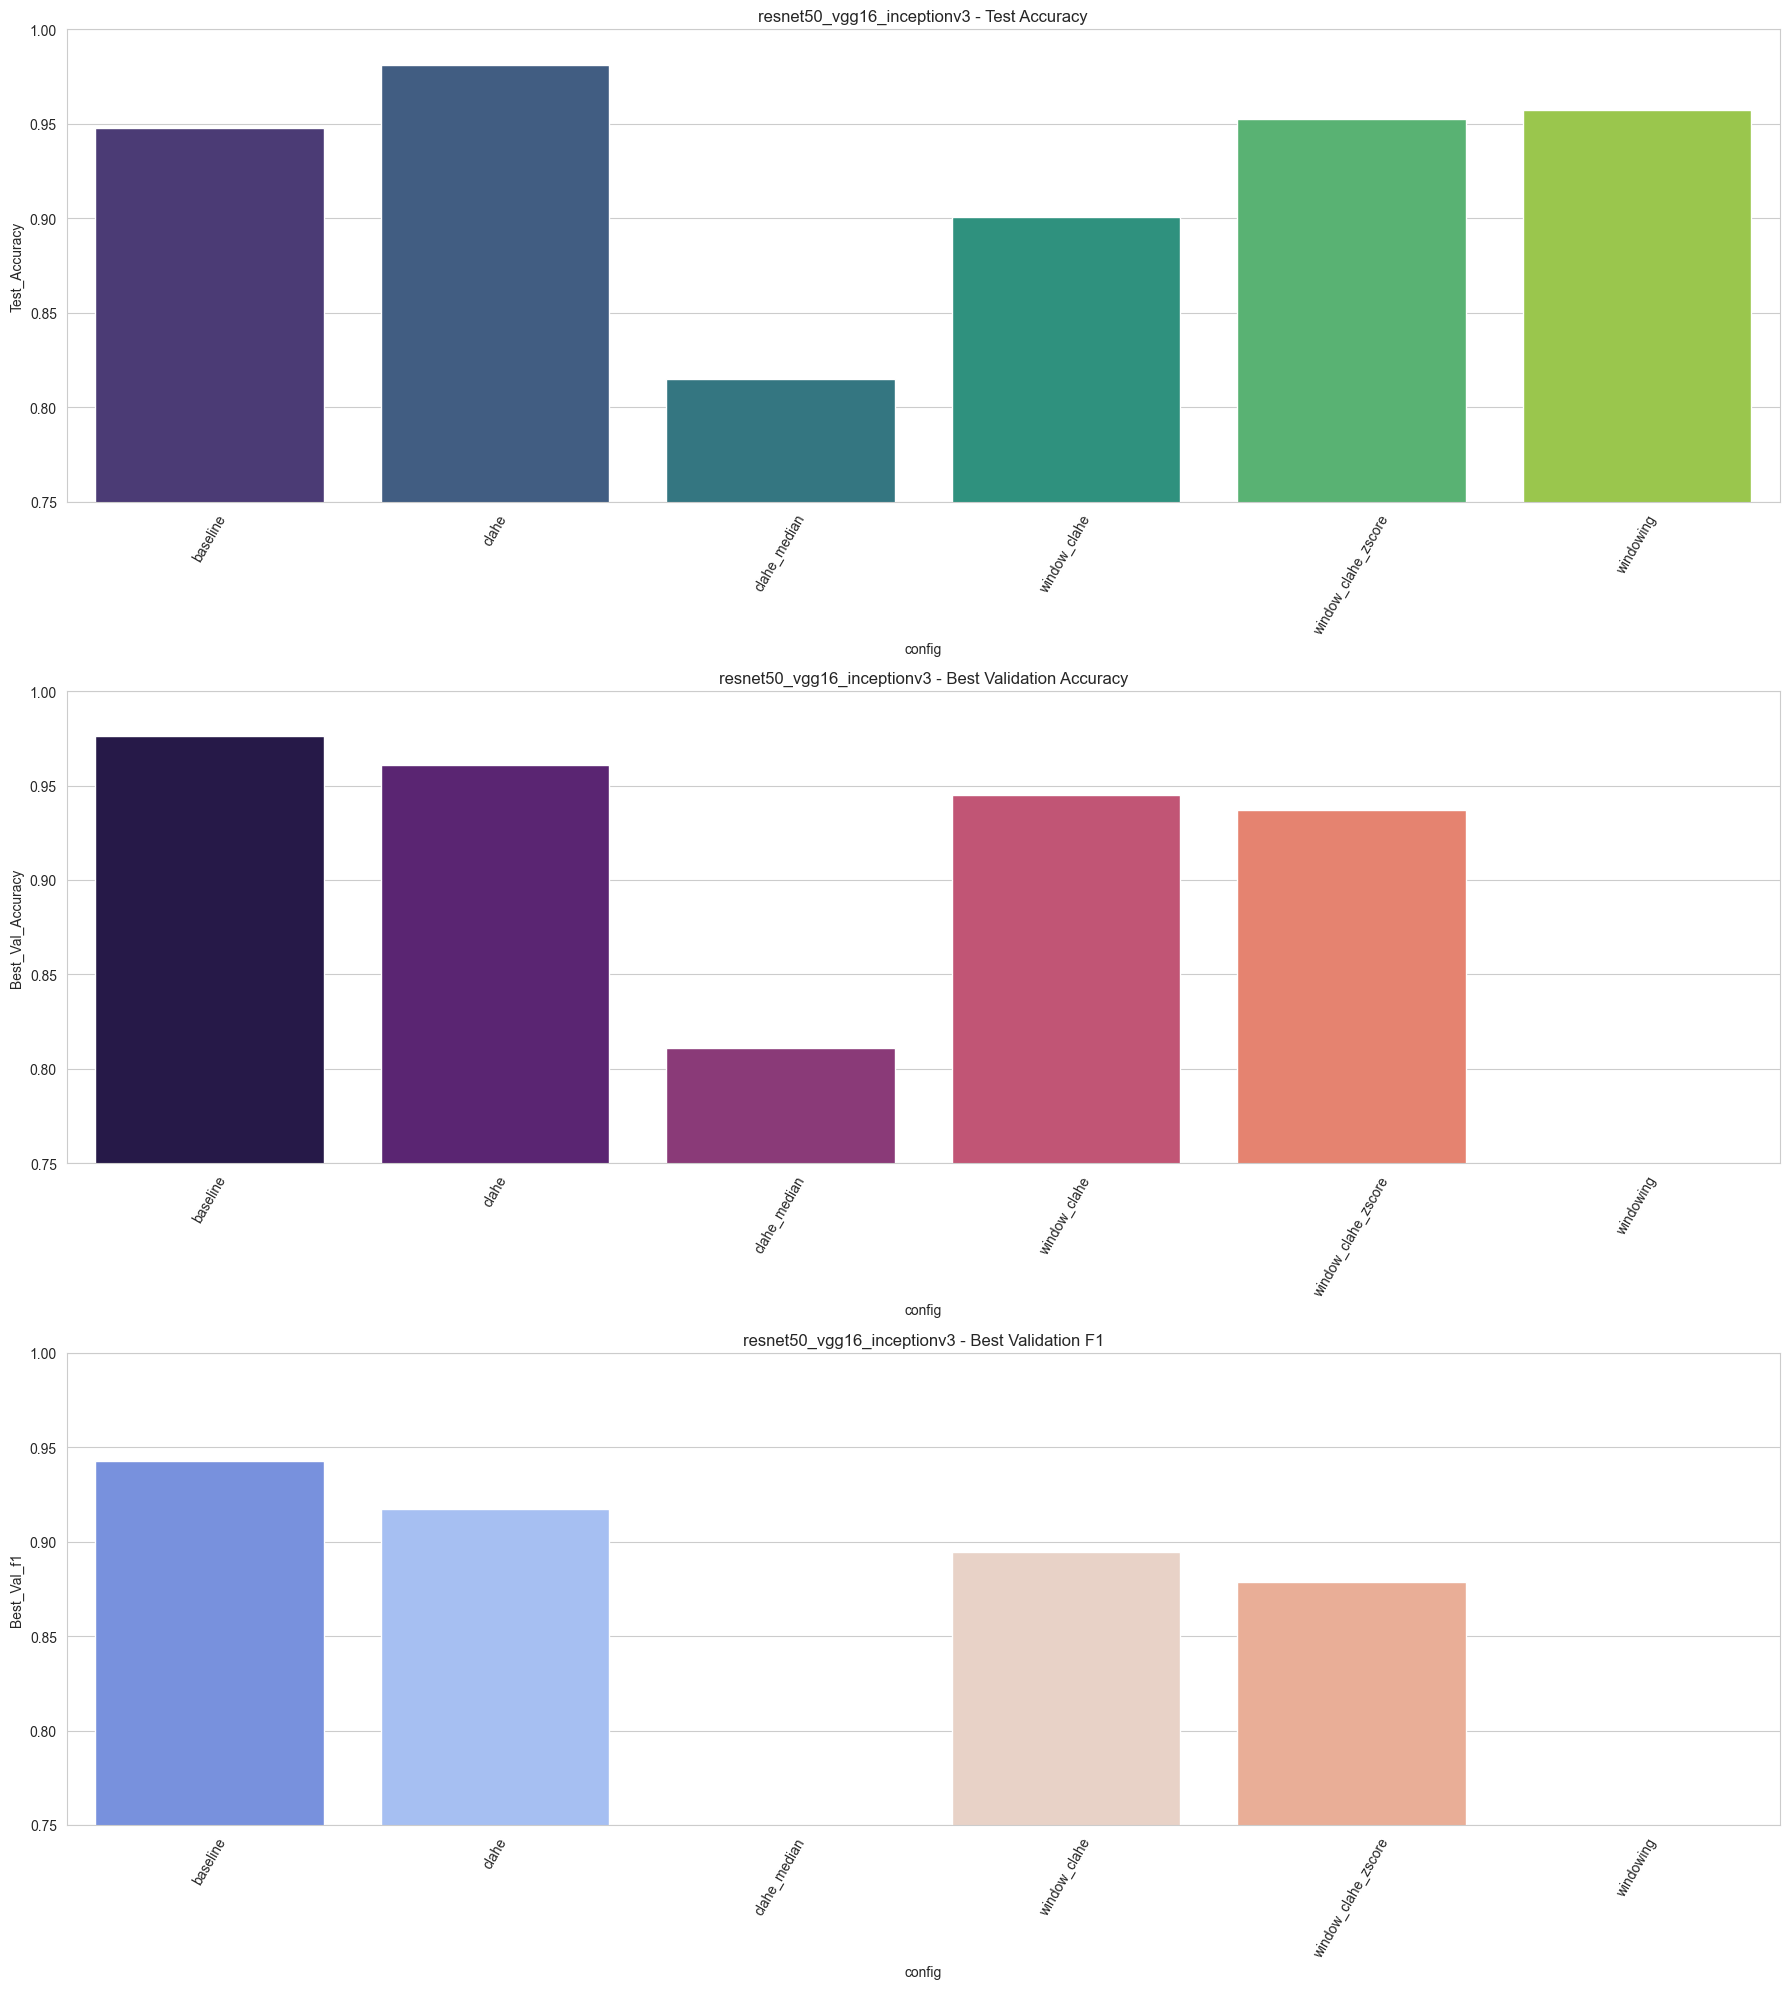

C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\navne\AppData\Local\Temp\ipykernel_3152\2312477033.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


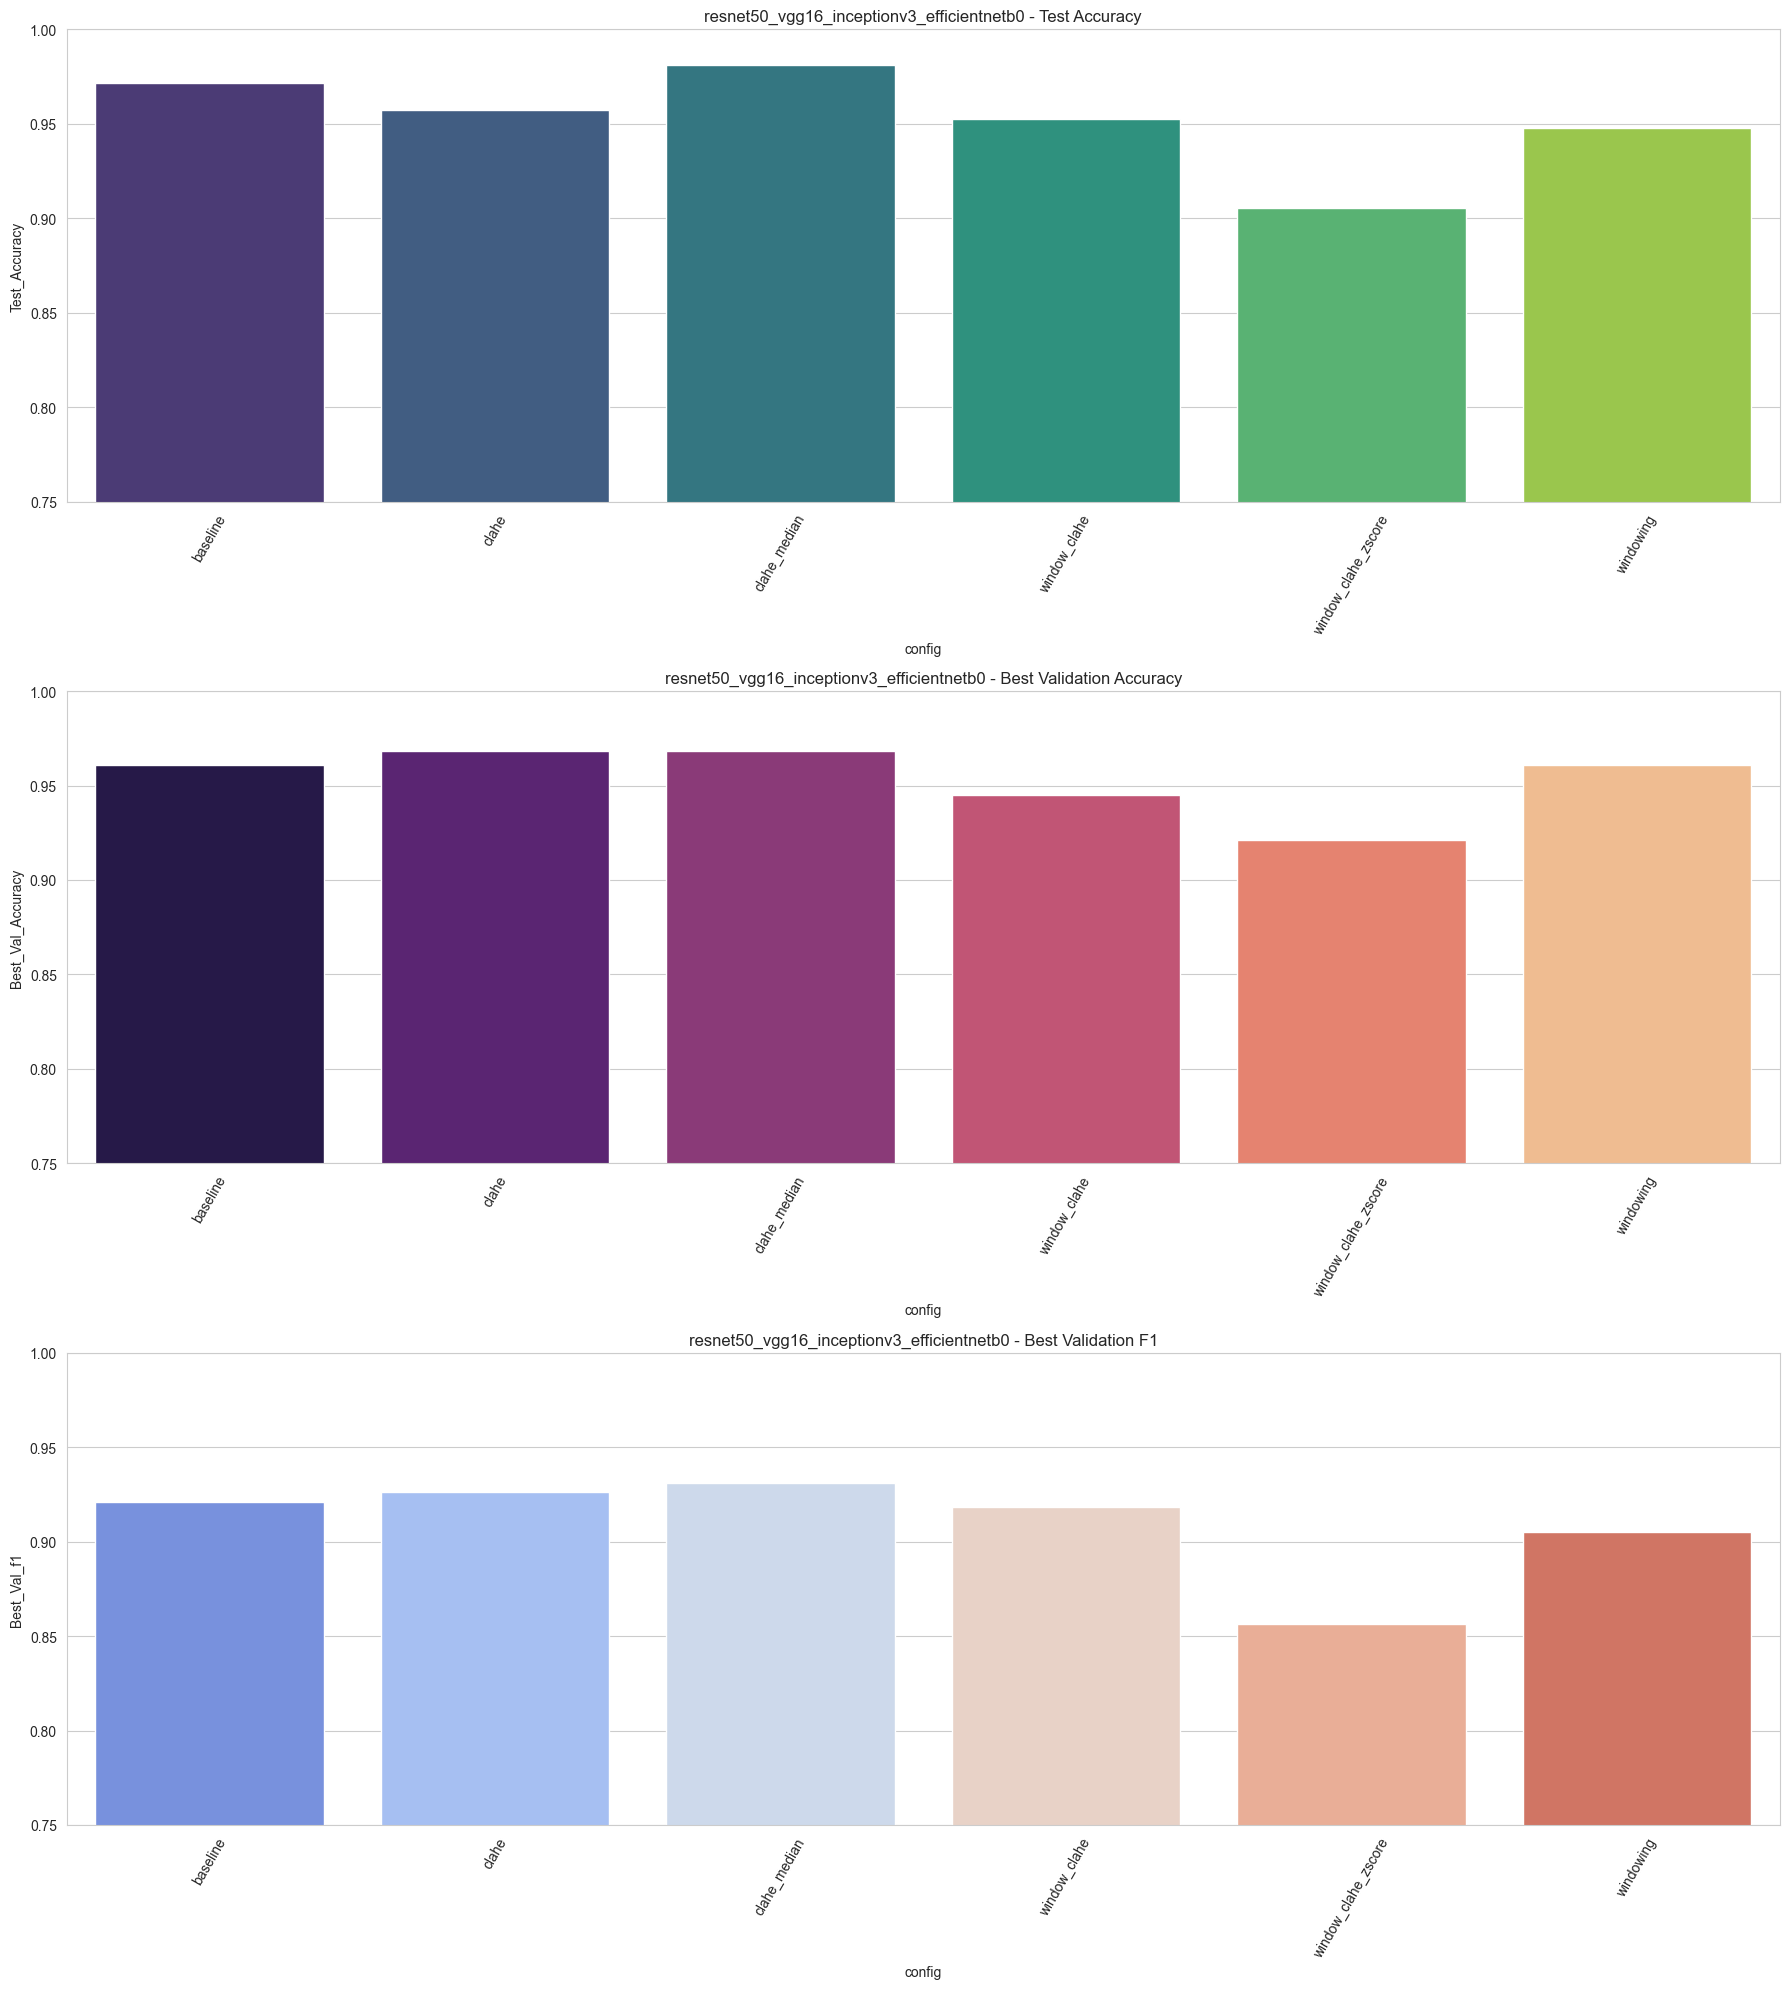

Charts generated successfully!


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("results/charts-seaborn/hybrid", exist_ok=True)

sns.set_style("whitegrid")

models = df["hybrid_model"].unique()

range = 0.75

for model in models:

    model_df = df[df["hybrid_model"] == model]
    model_df = model_df.sort_values("config")

    fig, axes = plt.subplots(3, 1, figsize=(18, 20))

    # -------- Test Accuracy --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Test_Accuracy",
        ax=axes[0],
        palette="viridis"
    )

    axes[0].set_title(f"{model} - Test Accuracy")
    axes[0].set_ylim(range, 1)
    axes[0].tick_params(axis='x', rotation=60)

    # -------- Validation Accuracy --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Best_Val_Accuracy",
        ax=axes[1],
        palette="magma"
    )

    axes[1].set_title(f"{model} - Best Validation Accuracy")
    axes[1].set_ylim(range, 1)
    axes[1].tick_params(axis='x', rotation=60)

    # -------- Validation F1 --------
    sns.barplot(
        data=model_df,
        x="config",
        y="Best_Val_f1",
        ax=axes[2],
        palette="coolwarm"
    )

    axes[2].set_title(f"{model} - Best Validation F1")
    axes[2].set_ylim(range, 1)
    axes[2].tick_params(axis='x', rotation=60)

    plt.tight_layout()
    plt.savefig(f"results/charts-seaborn/hybrid/{model}_performance.png")
    plt.show()
    plt.close()

print("Charts generated successfully!")